# GHG Spatial Analysis v2 — Thailand Rice CH₄ Emissions (SF_w Differentiated)
**IPEN6100F Final Project**

**v2 vs v1 (ghg_spatial_analysis.ipynb):**
- **SF_w differentiation per IPCC 2006 Table 5.12:**
  - Northeast + South → SF_w = 0.52 (rainfed lowland, regular flooding)
  - Central + North → SF_w = 1.0 (continuously flooded, irrigated)
- National trend (Plot 1) retains SF_w = 1.0 (standard Tier 1 national inventory baseline)
- All provincial plots (choropleth, intensity, top-20) reflect corrected emission factors

**Corresponding paper version:** `main_v2.tex`

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "grid.alpha":         0.25,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "legend.framealpha":  0.9,
    "legend.fontsize":    9,
})

# ── Region classification ────────────────────────────────────────────────────
REGION_MAP = {
    "Chiang Rai":"North","Phayao":"North","Lampang":"North","Lamphun":"North",
    "Chiang Mai":"North","Mae Hong Son":"North","Tak":"North","Sukhothai":"North",
    "Uttaradit":"North","Phrae":"North","Nan":"North","Phitsanulok":"North",
    "Phichit":"North","Kamphaeng Phet":"North","Phetchabun":"North",
    "Nong Khai":"Northeast","Nong Bua Lamphu":"Northeast","Udon Thani":"Northeast",
    "Loei":"Northeast","Sakon Nakhon":"Northeast","Nakhon Phanom":"Northeast",
    "Mukdahan":"Northeast","Yasothon":"Northeast","Amnat Charoen":"Northeast",
    "Ubon Ratchathani":"Northeast","Si Sa Ket":"Northeast","Surin":"Northeast",
    "Buri Ram":"Northeast","Maha Sarakham":"Northeast","Roi Et":"Northeast",
    "Kalasin":"Northeast","Khon Kaen":"Northeast","Chaiyaphum":"Northeast",
    "Nakhon Ratchasima":"Northeast","Bueng Kan":"Northeast",
    "Saraburi":"Central","Lopburi":"Central","Sing Buri":"Central",
    "Chai Nat":"Central","Suphan Buri":"Central","Ang Thong":"Central",
    "Phra Nakhon Si Ayutthaya":"Central","Nakhon Sawan":"Central",
    "Uthai Thani":"Central","Nonthaburi":"Central","Pathum Thani":"Central",
    "Bangkok":"Central","Nakhon Pathom":"Central","Samut Sakhon":"Central",
    "Samut Songkhram":"Central","Samut Prakan":"Central","Ratchaburi":"Central",
    "Kanchanaburi":"Central","Phetchaburi":"Central","Prachuap Khiri Khan":"Central",
    "Chachoengsao":"Central","Prachin Buri":"Central","Nakhon Nayok":"Central",
    "Sa Kaeo":"Central","Chon Buri":"Central","Rayong":"Central",
    "Chanthaburi":"Central","Trat":"Central",
}

# ── Region & season colours (used consistently across all plots) ─────────────
REGION_COLORS  = {"Northeast":"#d62728", "Central":"#2ca02c",
                  "North":"#1f77b4",     "South":"#ff7f00"}
SEASON_COLORS  = {"main":"#e07b39", "dry":"#4a90c4"}   # Plot 3 / captions

# ── IPCC 2006 Tier 1 parameters ──────────────────────────────────────────────
EF_c = 1.30   # kg CH4/ha/day (IPCC 2006 Table 5.11)
GWP  = 28     # AR5 100-yr (Myhre et al. 2013)
# t_p from Buddhaboon et al. 2011, Field Crops Res. 124:270-277 (Thailand field data)
T_P  = {"main": 118, "dry": 111}

def get_ef(season):
    return EF_c * T_P[season]

print("Seasonal EF (kg CH4/ha) — uniform Tier 1:")
for s in ["main", "dry"]:
    print(f"  {s:5s}: {get_ef(s):.1f}")

Seasonal EF (kg CH4/ha) — uniform Tier 1:
  main : 153.4
  dry  : 144.3


In [2]:
# ── Load & calculate provincial emissions ───────────────────────────────────
df = pd.read_csv("../data/processed/oae_provincial_rice_2022_2024.csv")
df["region"]   = df["province_en"].map(REGION_MAP).fillna("South")

# IPCC 2006 Table 5.12 — regional water regime defaults
# SF_w = 0.52: rainfed lowland regular flooding (NE + South)
# SF_w = 1.00: continuously flooded irrigated (Central + North)
SF_W_MAP = {"Northeast": 0.52, "South": 0.52, "Central": 1.0, "North": 1.0}
df["SF_w"] = df["region"].map(SF_W_MAP).fillna(1.0)

# Province-level overrides: peripheral/marginal provinces whose administrative
# region (Central or North) does not reflect their actual water management regime
PROVINCE_OVERRIDES_RAINFED = {
    # Eastern Central — outside Chao Phraya irrigation network
    "Sa Kaeo", "Chanthaburi", "Trat", "Prachin Buri",
    "Rayong", "Chon Buri", "Nakhon Nayok",
    # Highland/Remote North — mountain or upland rice, no lowland irrigation
    "Mae Hong Son", "Tak",
}
mask = df["province_en"].isin(PROVINCE_OVERRIDES_RAINFED)
df.loc[mask, "SF_w"] = 0.52
print(f"Province overrides → SF_w=0.52: {sorted(PROVINCE_OVERRIDES_RAINFED)}")
print(f"  Rows adjusted: {mask.sum()}")

df["EF_kg_ha"] = df["season"].map(T_P) * EF_c * df["SF_w"]
df["CH4_Gg"]   = df["area_harvested_ha"] * df["EF_kg_ha"] * 1e-6
df["CO2e_Gg"]  = df["CH4_Gg"] * GWP

# Annual total per province (both seasons combined)
annual = (
    df.groupby(["year_CE", "province_en", "region"])
    .agg(area_ha      = ("area_harvested_ha", "sum"),
         production_t = ("production_ton",    "sum"),
         CH4_Gg       = ("CH4_Gg",            "sum"),
         CO2e_Gg      = ("CO2e_Gg",           "sum"))
    .reset_index()
)
annual["intensity_kgCH4_t"] = (annual["CH4_Gg"] * 1e6) / annual["production_t"]

# 3-year mean per province (2022-2024)
mean_prov = (
    annual[annual["year_CE"] <= 2024]
    .groupby(["province_en", "region"])
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("CH4_Gg", ascending=False)
    .reset_index(drop=True)
)

total_ch4 = mean_prov["CH4_Gg"].sum()
print(f"\nProvinces: {len(mean_prov)}")
print(f"Total mean annual CH4: {total_ch4:.1f} Gg CH4/yr")
print(f"\nRegional breakdown:")
reg = mean_prov.groupby("region")["CH4_Gg"].sum().sort_values(ascending=False)
for r, v in reg.items():
    print(f"  {r:12s}: {v:.1f} Gg ({v/total_ch4*100:.1f}%)")
print(f"\nTop 10 provinces:")
cols = ["province_en","region","area_ha","CH4_Gg","CO2e_Gg","intensity_kgCH4_t"]
print(mean_prov.head(10)[cols].to_string(index=False))
print(f"\nMean intensity by region (kg CH4/tonne rice):")
print(mean_prov.groupby("region")["intensity_kgCH4_t"].mean().sort_values(ascending=False).to_string())

Province overrides → SF_w=0.52: ['Chanthaburi', 'Chon Buri', 'Mae Hong Son', 'Nakhon Nayok', 'Prachin Buri', 'Rayong', 'Sa Kaeo', 'Tak', 'Trat']
  Rows adjusted: 56

Provinces: 77
Total mean annual CH4: 1202.1 Gg CH4/yr

Regional breakdown:
  Northeast   : 482.0 Gg (40.1%)
  Central     : 376.1 Gg (31.3%)
  North       : 329.9 Gg (27.4%)
  South       : 14.0 Gg (1.2%)

Top 10 provinces:
      province_en    region       area_ha    CH4_Gg     CO2e_Gg  intensity_kgCH4_t
     Nakhon Sawan   Central 477745.493333 72.442404 2028.387305          40.500570
          Phichit     North 367875.893333 55.662281 1558.543859          39.423771
 Ubon Ratchathani Northeast 662243.146667 52.707545 1475.811250          34.714529
      Phitsanulok     North 331384.320000 49.918898 1397.729133          40.228546
      Suphan Buri   Central 331042.133333 49.591596 1388.564698          33.588135
Nakhon Ratchasima Northeast 564482.826667 44.868065 1256.305833          32.817318
            Surin Northeast 4

## Plot 1 — National Trend with Regression (1961–2024)

Trend: +11.95 Gg CH4/yr  |  R²=0.830  |  p=1.43e-25


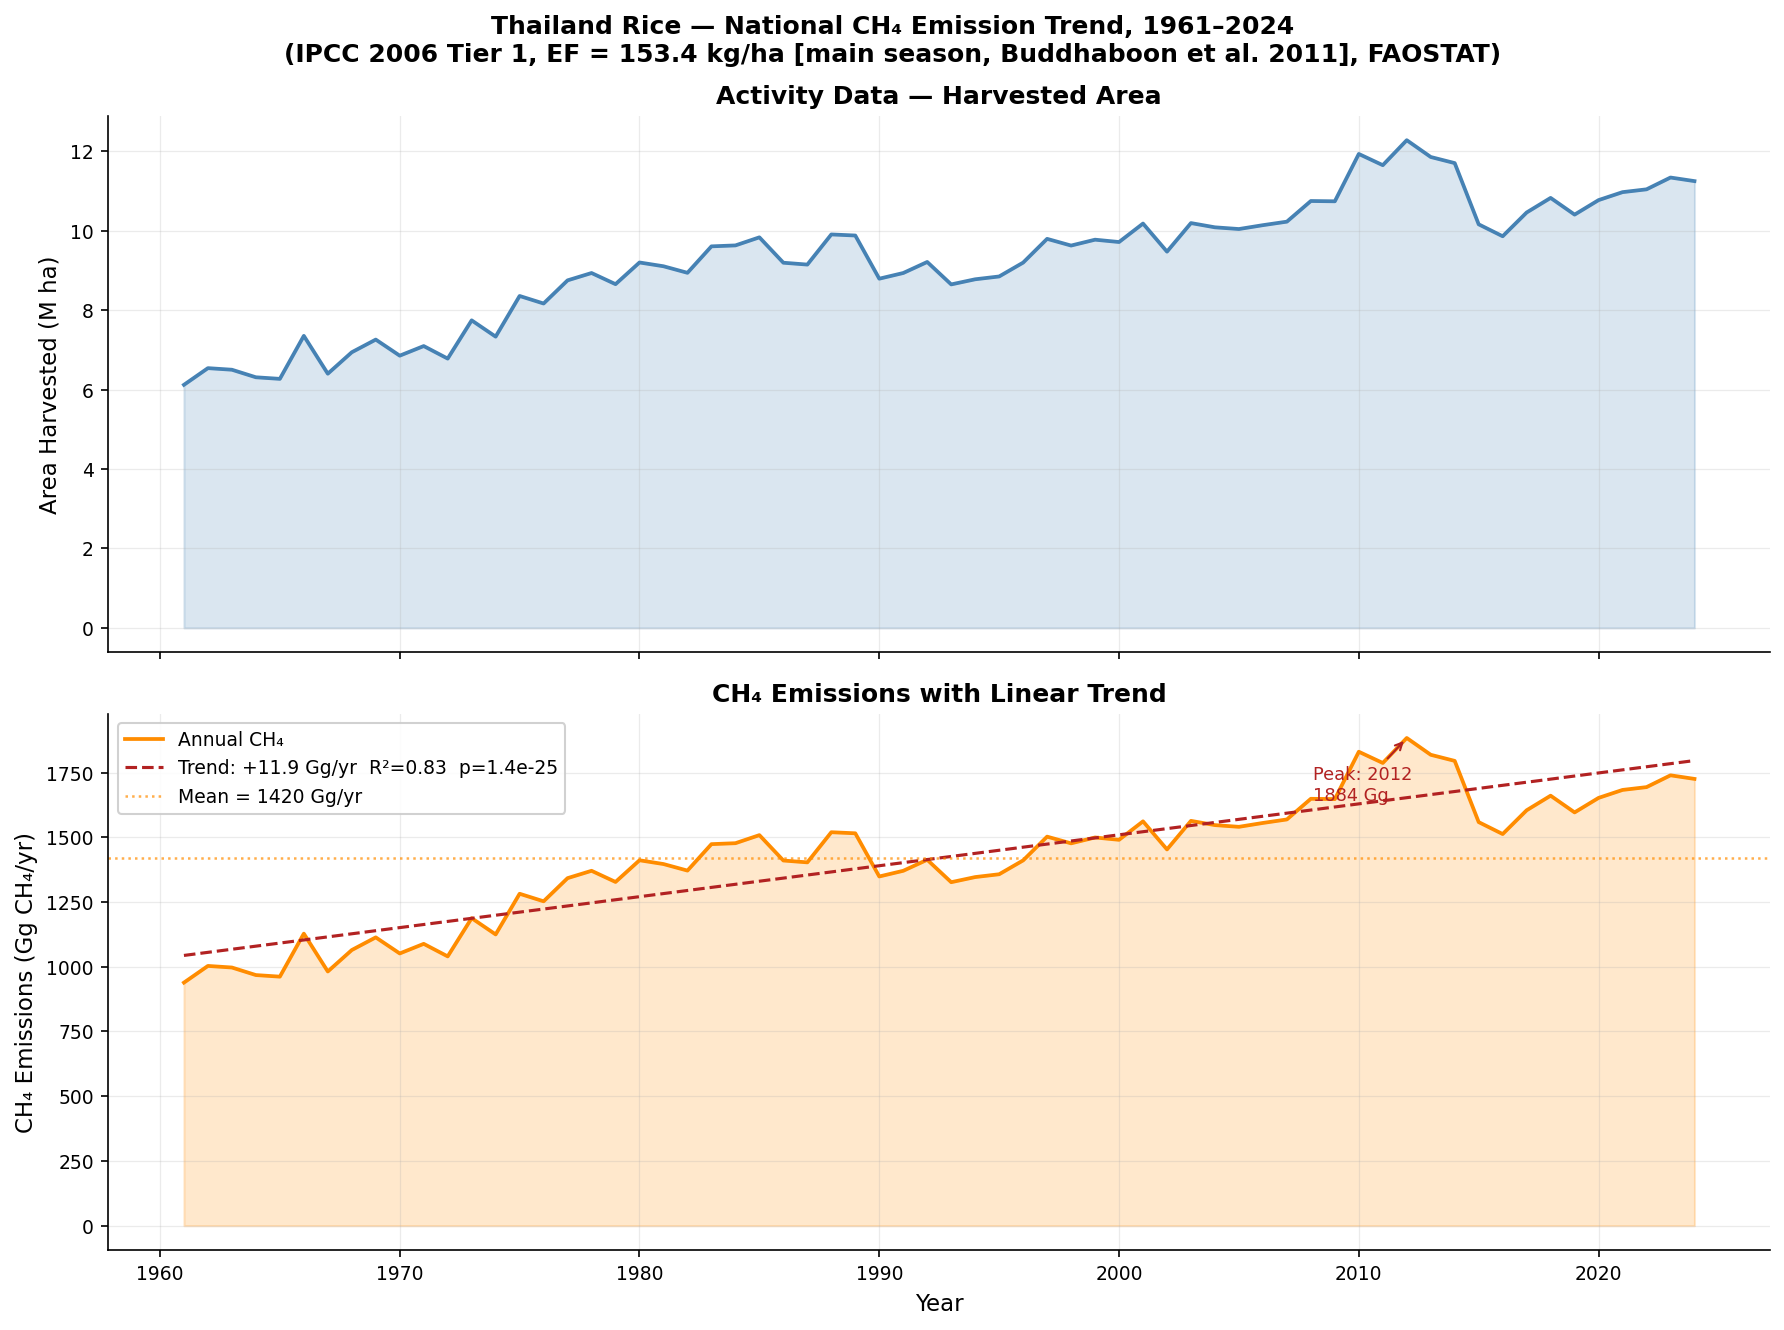


Min: 938.8 Gg (1961)
Peak: 1883.6 Gg (2012)
2024: 1725.5 Gg


In [3]:
nat = pd.read_csv("../data/raw/faostat_thailand_rice_1961_2024.csv")
area_df = (nat[nat["Element"] == "Area harvested"]
           .rename(columns={"Year":"year","Value":"area_ha"})
           [["year","area_ha"]].dropna().sort_values("year"))
area_df["CH4_Gg"] = area_df["area_ha"] * 153.4 * 1e-6  # main season EF (Buddhaboon et al. 2011)

slope, intercept, r, p, se = stats.linregress(area_df["year"], area_df["CH4_Gg"])
r2 = r**2
trend_y = slope * area_df["year"] + intercept
print(f"Trend: +{slope:.2f} Gg CH4/yr  |  R²={r2:.3f}  |  p={p:.2e}")

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Thailand Rice — National CH₄ Emission Trend, 1961–2024\n"
             "(IPCC 2006 Tier 1, EF = 153.4 kg/ha [main season, Buddhaboon et al. 2011], FAOSTAT)", fontsize=12, fontweight="bold")

ax1, ax2 = axes
years = area_df["year"]

ax1.fill_between(years, area_df["area_ha"]/1e6, alpha=0.2, color="steelblue")
ax1.plot(years, area_df["area_ha"]/1e6, color="steelblue", lw=1.8)
ax1.set_ylabel("Area Harvested (M ha)")
ax1.set_title("Activity Data — Harvested Area")
ax1.grid(True)

ax2.fill_between(years, area_df["CH4_Gg"], alpha=0.2, color="darkorange")
ax2.plot(years, area_df["CH4_Gg"], color="darkorange", lw=1.8, label="Annual CH₄")
ax2.plot(years, trend_y, "--", color="firebrick", lw=1.5,
         label=f"Trend: +{slope:.1f} Gg/yr  R²={r2:.2f}  p={p:.1e}")
ax2.axhline(area_df["CH4_Gg"].mean(), color="darkorange", ls=":", lw=1.2, alpha=0.7,
            label=f"Mean = {area_df['CH4_Gg'].mean():.0f} Gg/yr")
ax2.set_ylabel("CH₄ Emissions (Gg CH₄/yr)")
ax2.set_title("CH₄ Emissions with Linear Trend")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True)

pk = area_df.loc[area_df["CH4_Gg"].idxmax()]
ax2.annotate(f"Peak: {int(pk['year'])}\n{pk['CH4_Gg']:.0f} Gg",
             xy=(pk["year"], pk["CH4_Gg"]), xytext=(-45, -30),
             textcoords="offset points", fontsize=8.5, color="firebrick",
             arrowprops=dict(arrowstyle="->", color="firebrick", lw=1))

plt.tight_layout()
plt.savefig("../figures/plot1_national_trend.png", bbox_inches="tight")
plt.show()
print(f"\nMin: {area_df['CH4_Gg'].min():.1f} Gg ({area_df.loc[area_df['CH4_Gg'].idxmin(),'year']})")
print(f"Peak: {area_df['CH4_Gg'].max():.1f} Gg ({area_df.loc[area_df['CH4_Gg'].idxmax(),'year']})")
print(f"2024: {area_df[area_df['year']==2024]['CH4_Gg'].values[0]:.1f} Gg")

## Plot 2 — Top 20 Provinces | Plot 3 — Regional × Season Bars

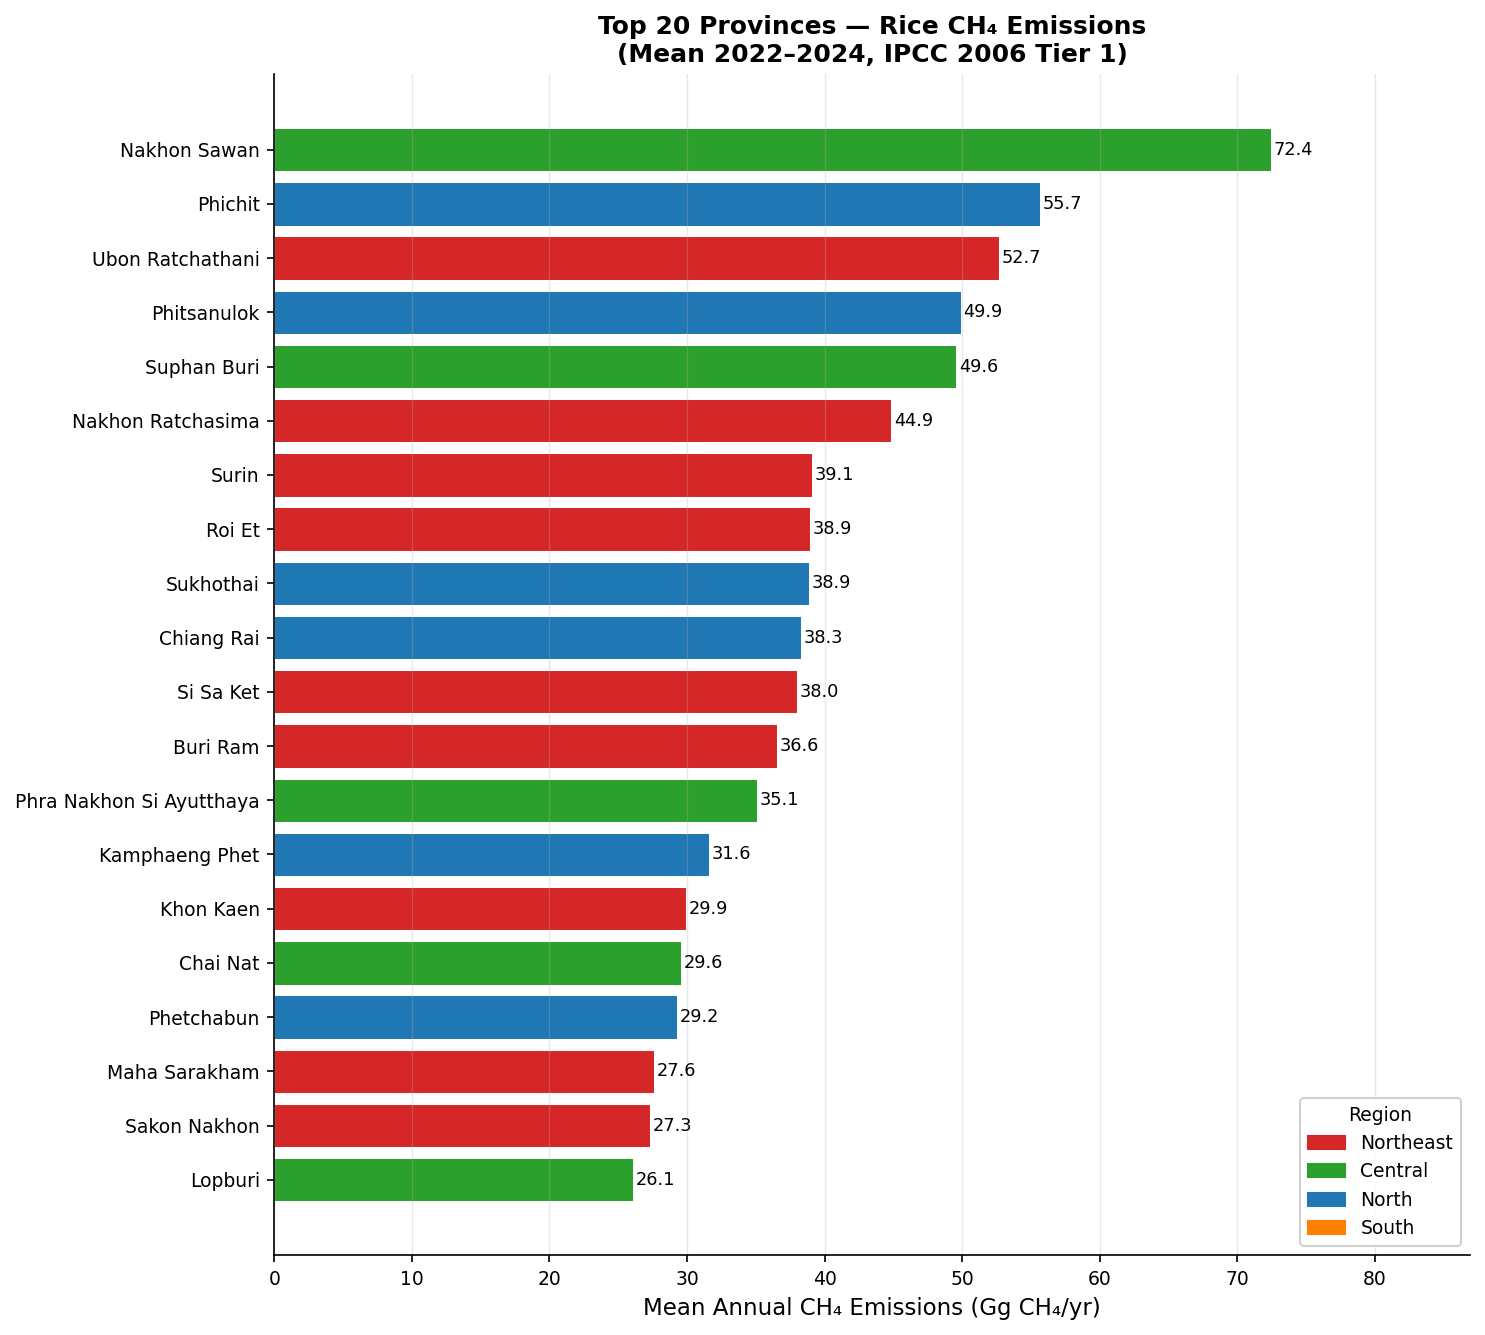

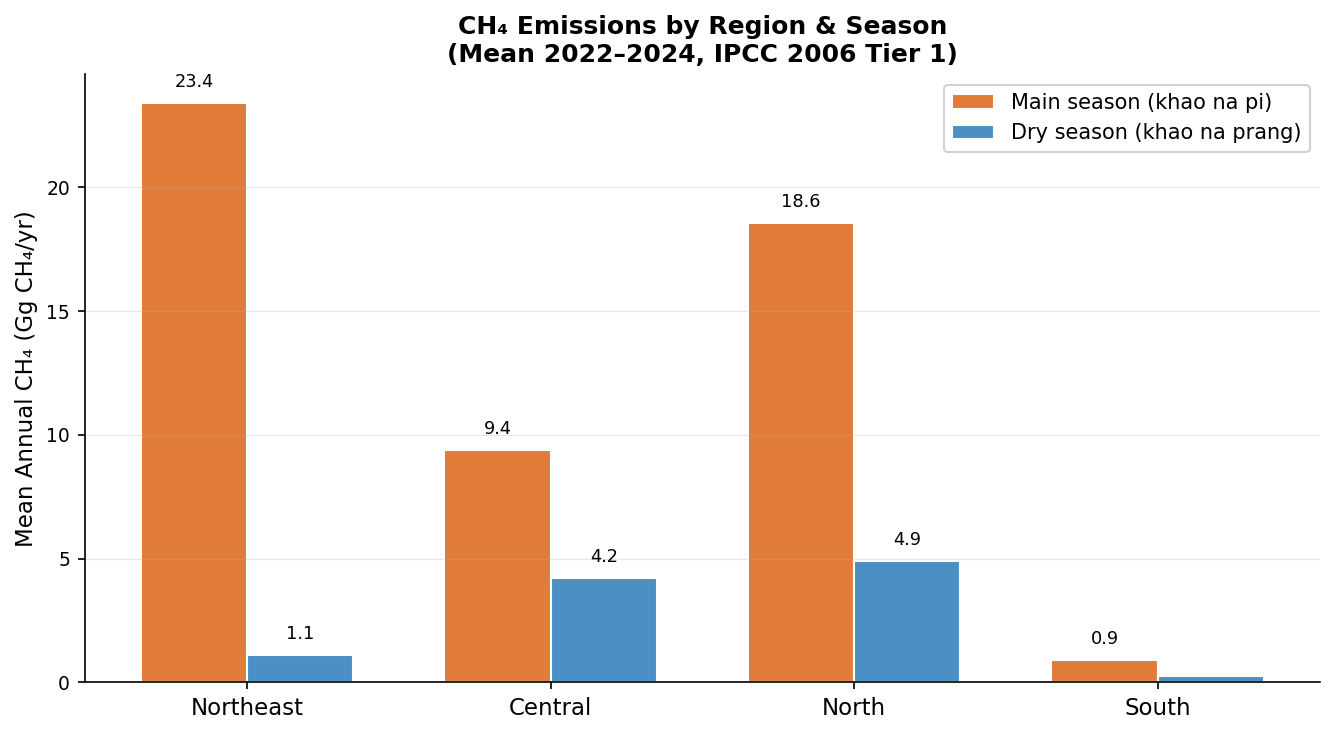

In [4]:
REGION_COLORS = {
    "Northeast": "#d62728",   # strong red
    "Central":   "#2ca02c",   # green
    "North":     "#1f77b4",   # blue
    "South":     "#ff7f00",   # orange
}

# ── Plot 2: Top 20 provinces ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
top20 = mean_prov.head(20).sort_values("CH4_Gg")
colors = [REGION_COLORS[r] for r in top20["region"]]
bars = ax.barh(top20["province_en"], top20["CH4_Gg"], color=colors, edgecolor="white", lw=0.5)
for bar, val in zip(bars, top20["CH4_Gg"]):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}", va="center", ha="left", fontsize=8.5)
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_handles, title="Region", fontsize=9, title_fontsize=9,
          loc="lower right")
ax.set_xlabel("Mean Annual CH₄ Emissions (Gg CH₄/yr)", fontsize=11)
ax.set_title("Top 20 Provinces — Rice CH₄ Emissions\n"
             "(Mean 2022–2024, IPCC 2006 Tier 1)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, top20["CH4_Gg"].max()*1.2)
ax.grid(axis="x", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/plot2_top20_provinces.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Regional x Season ────────────────────────────────────────────────
region_season = (
    df[df["year_CE"] <= 2024]
    .groupby(["region","season"])["CH4_Gg"].mean()
    .unstack("season").fillna(0)
    .loc[["Northeast","Central","North","South"]]
)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(region_season)); w = 0.35
b1 = ax.bar(x-w/2, region_season.get("main",0), w,
            label="Main season (khao na pi)", color="#e07b39", edgecolor="white")
b2 = ax.bar(x+w/2, region_season.get("dry",0),  w,
            label="Dry season (khao na prang)", color="#4a90c4", edgecolor="white")
for b in [b1, b2]:
    for bar in b:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f"{h:.1f}",
                    ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(region_season.index, fontsize=11)
ax.set_ylabel("Mean Annual CH₄ (Gg CH₄/yr)", fontsize=11)
ax.set_title("CH₄ Emissions by Region & Season\n"
             "(Mean 2022–2024, IPCC 2006 Tier 1)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/plot3_region_season.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 4 — Choropleth Map with North Arrow & Scale Bar

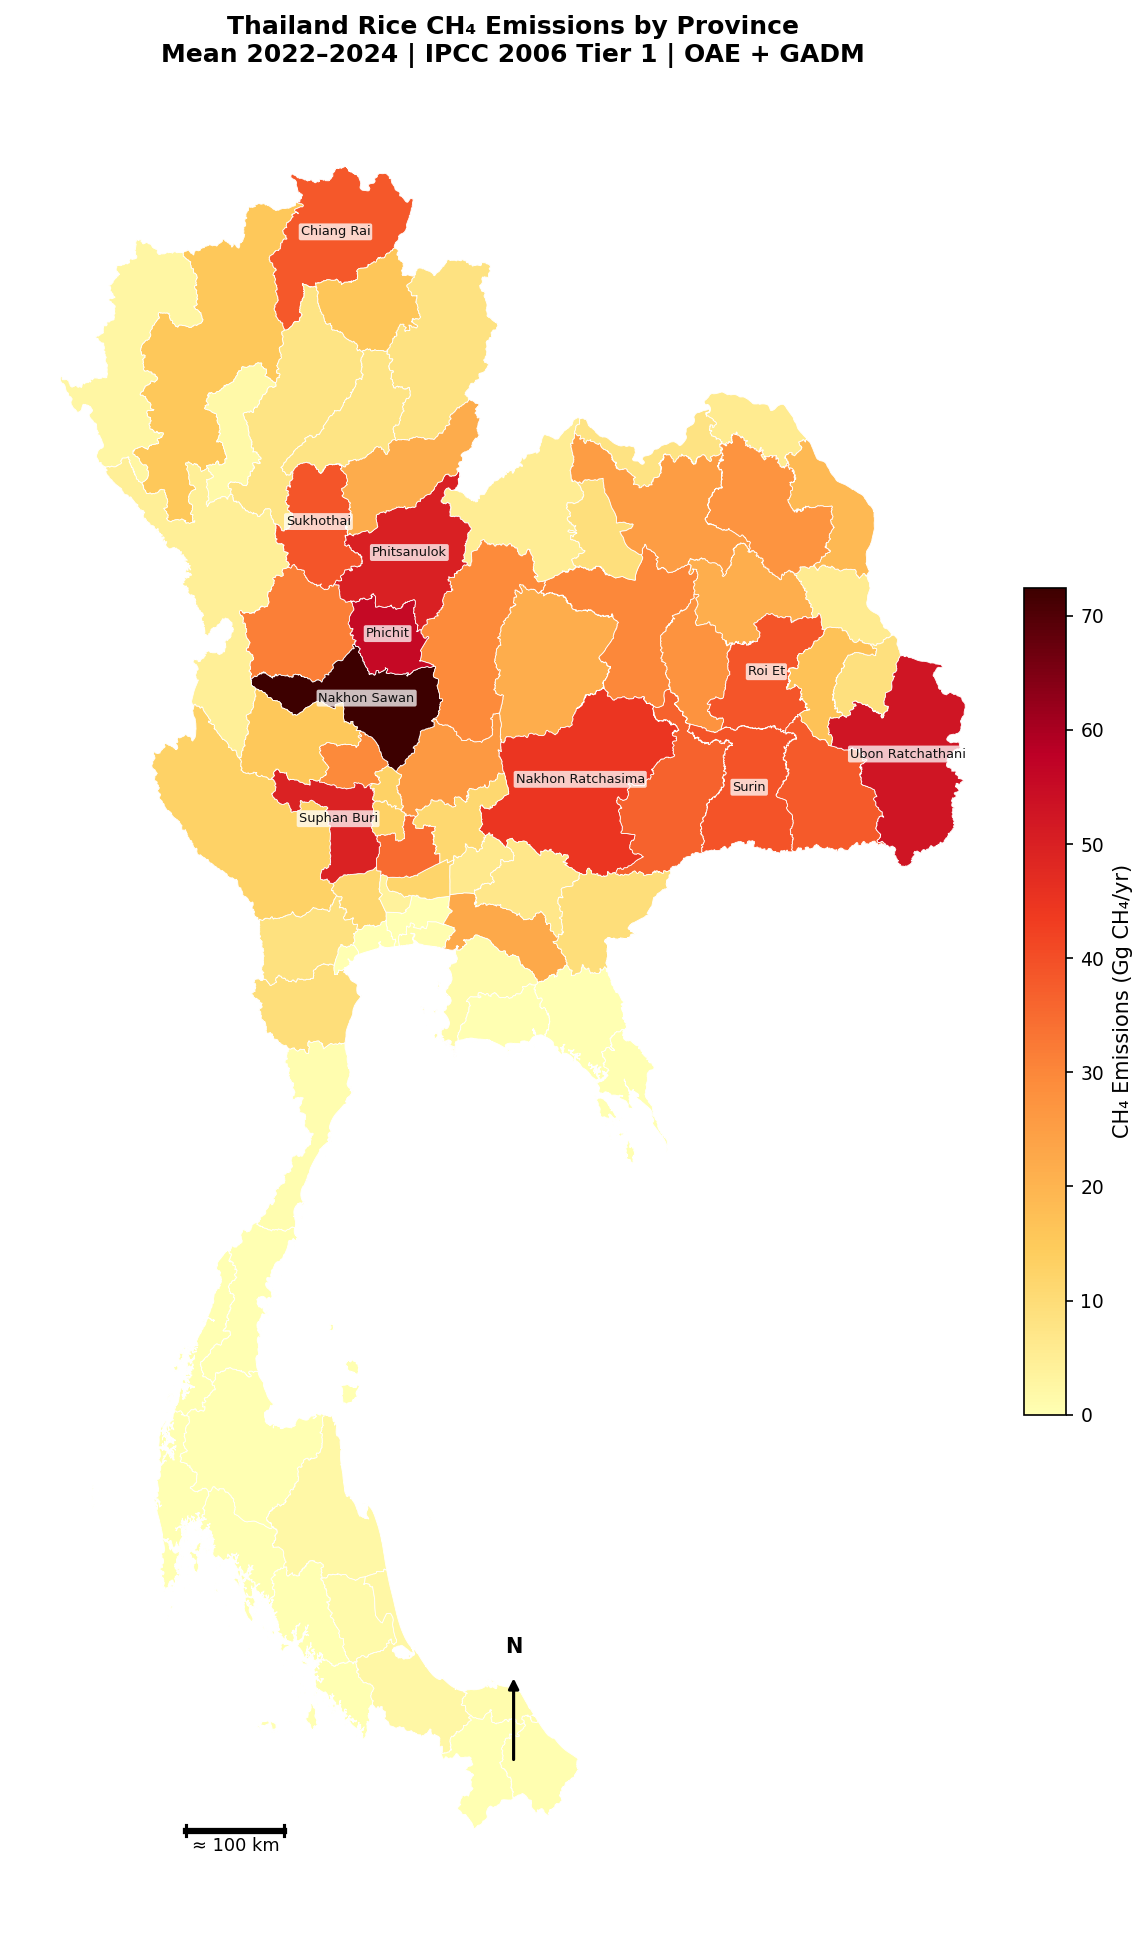

In [5]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Continuous gradient: pale yellow → orange → red → near-black
cmap_yor = LinearSegmentedColormap.from_list(
    "yor_dark",
    ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026", "#3d0000"],
    N=256
)

GADM_FIX = {
    "Krung Thep Maha Nakhon":"Bangkok","Lop Buri":"Lopburi",
    "Nong Bua Lam Phu":"Nong Bua Lamphu",
    "Phra Nakhon Si Ayutthaya":"Phra Nakhon Si Ayutthaya",
}
gdf = gpd.read_file("../data/raw/gadm_THA/gadm41_THA_1.shp")
gdf["province_en"] = gdf["NAME_1"].map(GADM_FIX).fillna(gdf["NAME_1"])
geo = gdf.merge(mean_prov[["province_en","CH4_Gg","CO2e_Gg","intensity_kgCH4_t"]],
                on="province_en", how="left")
geo["CH4_Gg"] = geo["CH4_Gg"].fillna(0)

vmin = geo["CH4_Gg"].min()
vmax = geo["CH4_Gg"].max()

fig, ax = plt.subplots(figsize=(10, 13))
geo.plot(column="CH4_Gg", ax=ax, cmap=cmap_yor,
         vmin=vmin, vmax=vmax,
         legend=False,
         edgecolor="white", linewidth=0.4,
         missing_kwds={"color":"#eeeeee","label":"No data"})

# Continuous colorbar
sm = ScalarMappable(cmap=cmap_yor, norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                    fraction=0.03, pad=0.01, shrink=0.45)
cbar.set_label("CH₄ Emissions (Gg CH₄/yr)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Label top 10 provinces
for _, row in mean_prov.head(10).iterrows():
    match = geo[geo["province_en"] == row["province_en"]]
    if match.empty: continue
    pt = match.geometry.iloc[0].centroid
    ax.annotate(row["province_en"], xy=(pt.x, pt.y), fontsize=6.2, ha="center",
                color="#111111",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))

# ── North arrow ──────────────────────────────────────────────────────────────
x0, y0 = 101.5, 6.2
ax.annotate("", xy=(x0, y0+0.8), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
ax.text(x0, y0+0.95, "N", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Scale bar ────────────────────────────────────────────────────────────────
sb_x, sb_y, sb_len = 98.5, 5.6, 0.9
ax.plot([sb_x, sb_x+sb_len], [sb_y, sb_y], "k-", lw=3)
ax.plot([sb_x, sb_x],               [sb_y-0.05, sb_y+0.05], "k-", lw=1.5)
ax.plot([sb_x+sb_len, sb_x+sb_len], [sb_y-0.05, sb_y+0.05], "k-", lw=1.5)
ax.text(sb_x+sb_len/2, sb_y-0.18, "≈ 100 km", ha="center", fontsize=8.5)

ax.set_axis_off()
ax.set_title("Thailand Rice CH₄ Emissions by Province\n"
             "Mean 2022–2024 | IPCC 2006 Tier 1 | OAE + GADM",
             fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("../figures/plot4_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — Emission Intensity (kg CH₄ per tonne of rice) by Province

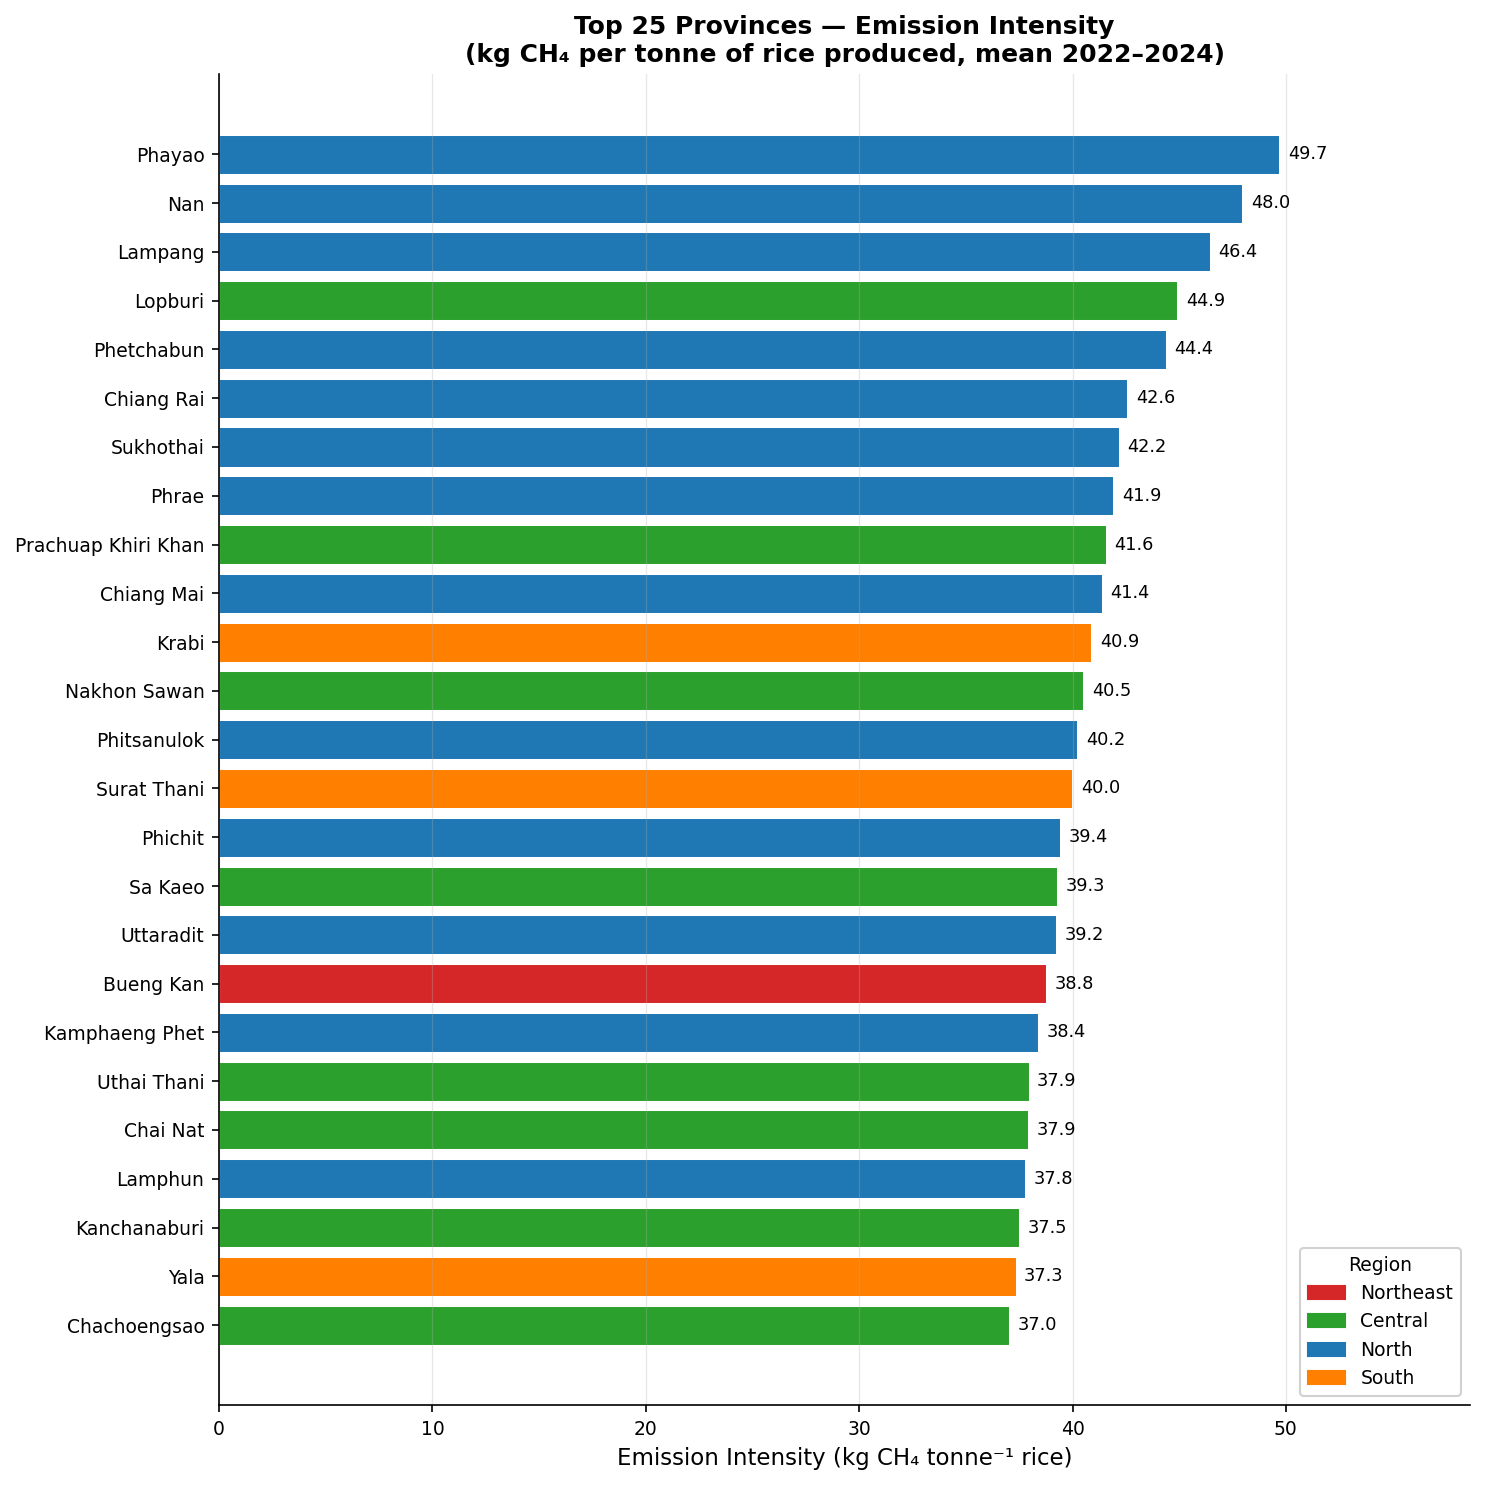

Mean intensity by region (kg CH4/tonne rice):
region
North        40.962193
Central      34.109712
Northeast    33.951348
South        31.436720


In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

top25_int = (mean_prov.dropna(subset=["intensity_kgCH4_t"])
             .nlargest(25, "intensity_kgCH4_t")
             .sort_values("intensity_kgCH4_t"))
colors = [REGION_COLORS[r] for r in top25_int["region"]]
bars = ax.barh(top25_int["province_en"], top25_int["intensity_kgCH4_t"],
               color=colors, edgecolor="white", lw=0.5)
for bar, val in zip(bars, top25_int["intensity_kgCH4_t"]):
    ax.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}", va="center", ha="left", fontsize=8.5)
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_handles, title="Region", fontsize=9, title_fontsize=9)
ax.set_xlabel("Emission Intensity (kg CH₄ tonne⁻¹ rice)", fontsize=11)
ax.set_title("Top 25 Provinces — Emission Intensity\n"
             "(kg CH₄ per tonne of rice produced, mean 2022–2024)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, top25_int["intensity_kgCH4_t"].max() * 1.18)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/plot5_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

reg_int = mean_prov.groupby("region")["intensity_kgCH4_t"].mean().sort_values(ascending=False)
print("Mean intensity by region (kg CH4/tonne rice):")
print(reg_int.to_string())

## Plot 6 — Rice Price vs FAOSTAT Statistics & CH₄: Policy Timeline (2007–2024)

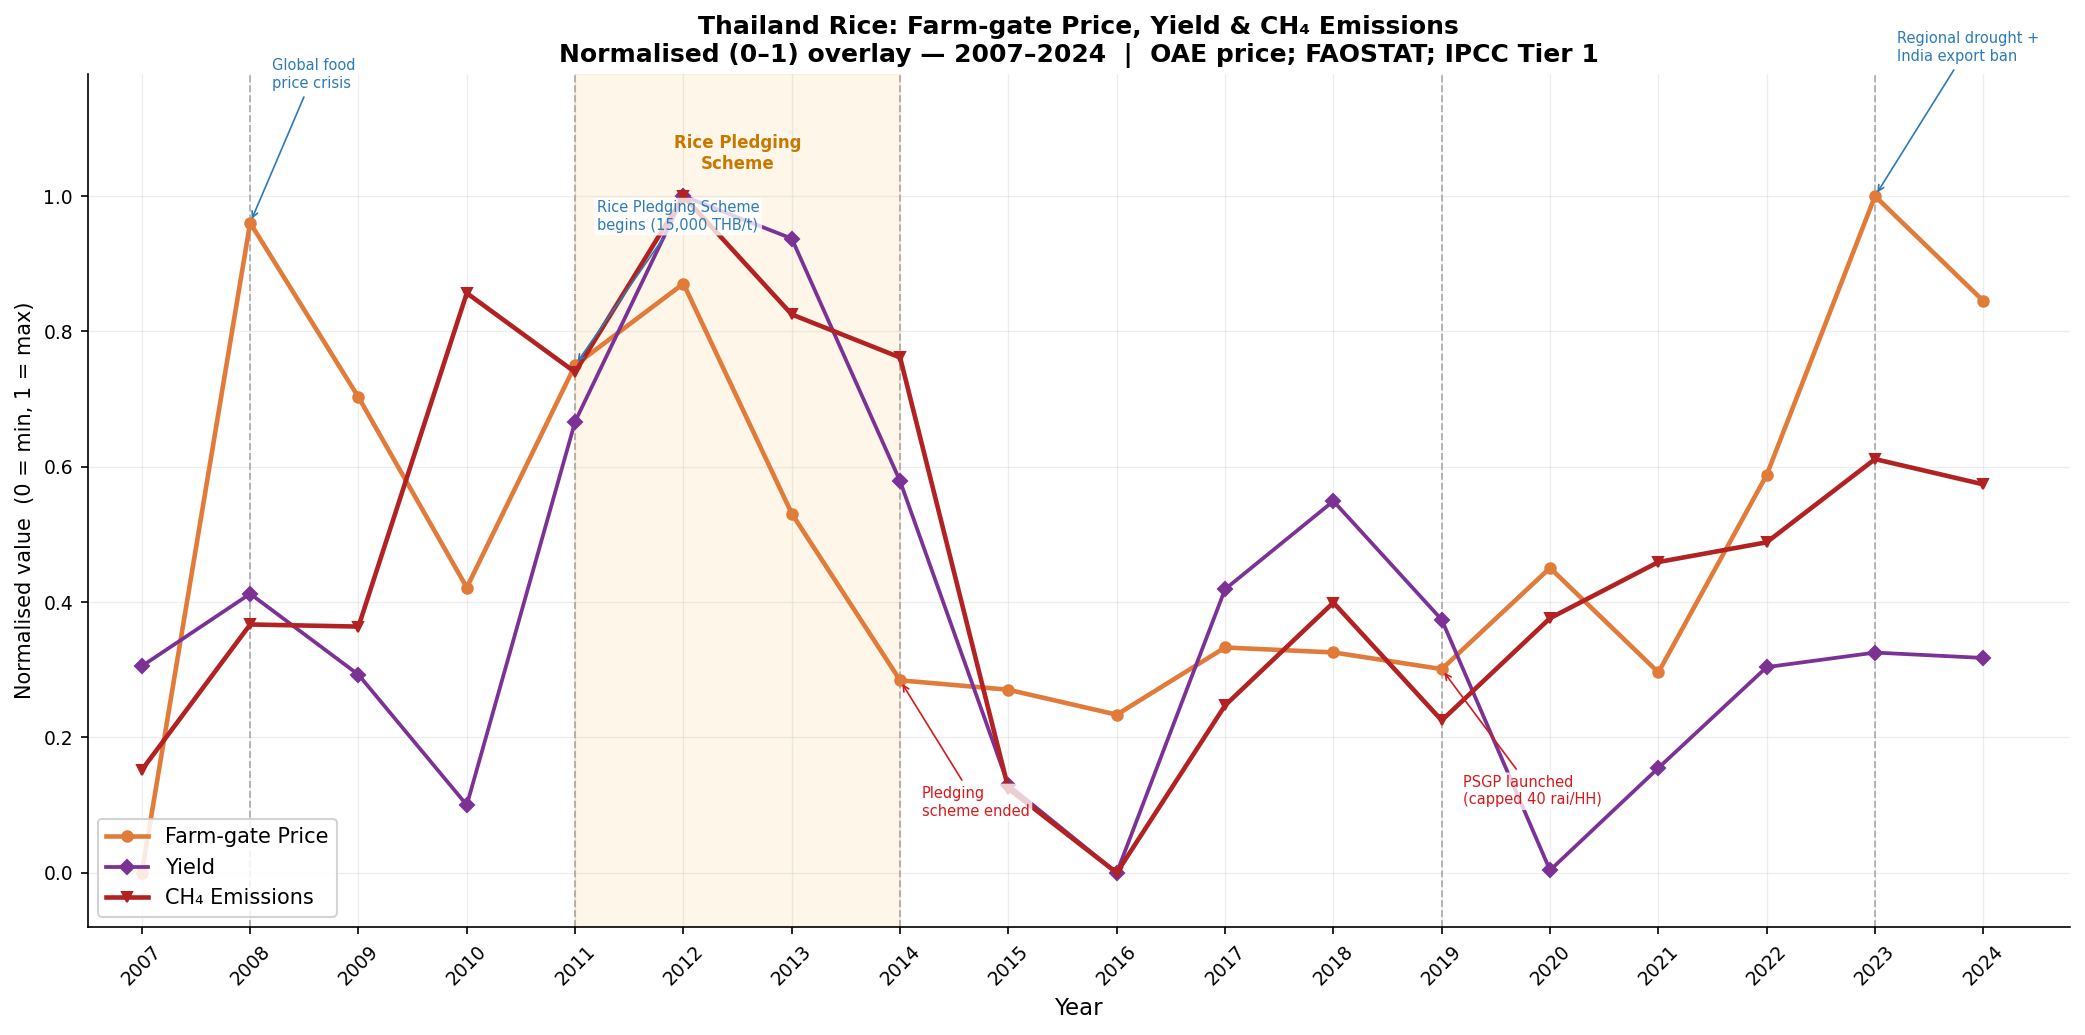

Pearson correlation with farm-gate price (2007–2024):
  Yield                 r=+0.338  p=0.170  
  CH4 Emissions         r=+0.505  p=0.033  *


In [7]:
# ── Load all FAOSTAT elements + price ────────────────────────────────────────
price_df = pd.read_csv("../data/processed/thailand_rice_price.csv")

nat = pd.read_csv("../data/raw/faostat_thailand_rice_1961_2024.csv")
area_df  = (nat[nat["Element"]=="Area harvested"]
            .rename(columns={"Year":"year","Value":"area_ha"})[["year","area_ha"]]
            .dropna().sort_values("year"))
prod_df  = (nat[nat["Element"]=="Production"]
            .rename(columns={"Year":"year","Value":"production_t"})[["year","production_t"]]
            .dropna().sort_values("year"))
yield_df = (nat[nat["Element"]=="Yield"]
            .rename(columns={"Year":"year","Value":"yield_kg_ha"})[["year","yield_kg_ha"]]
            .dropna().sort_values("year"))
area_df["CH4_Gg"] = area_df["area_ha"] * 153.4 * 1e-6

merged = (area_df[area_df["year"] >= 2007]
          .merge(prod_df,  on="year", how="left")
          .merge(yield_df, on="year", how="left")
          .merge(price_df, on="year", how="left"))

def norm(s): return (s - s.min()) / (s.max() - s.min())

# Harvested Area and Production both omitted:
# - Under Tier 1, CH4 = area × constant EF → CH4 and Area are perfectly collinear.
# - Production closely shadows Area (correlation > 0.95), adding noise not signal.
# Remaining three lines (Price, Yield, CH4) each carry independent information.
VARS = {
    "price_baht_tonne": ("Farm-gate Price",  "#e07b39", 2.2, "o"),
    "yield_kg_ha":      ("Yield",            "#7b3294",  1.8, "D"),
    "CH4_Gg":           ("CH₄ Emissions",    "firebrick",2.2, "v"),
}

POLICIES = [
    (2008, "Global food\nprice crisis",           "top"),
    (2011, "Rice Pledging Scheme\nbegins (15,000 THB/t)", "top"),
    (2014, "Pledging\nscheme ended",               "bottom"),
    (2019, "PSGP launched\n(capped 40 rai/HH)",   "bottom"),
    (2023, "Regional drought +\nIndia export ban", "top"),
]
POL_COL = {"top": "#2c7bb6", "bottom": "#d7191c"}

fig, ax = plt.subplots(figsize=(14, 7))
ax.axvspan(2011, 2014, alpha=0.10, color="#f9a825", zorder=0)
ax.text(2012.5, 1.04, "Rice Pledging\nScheme", ha="center", fontsize=8,
        color="#c77800", fontweight="bold")

yrs = merged["year"].values
for col, (label, color, lw, marker) in VARS.items():
    y = norm(merged[col].values)
    ax.plot(yrs, y, color=color, lw=lw, marker=marker, ms=5, label=label, zorder=3)

for yr, label, pos in POLICIES:
    ax.axvline(yr, color="gray", ls="--", lw=0.9, alpha=0.6, zorder=1)
    row = merged[merged["year"] == yr]
    if row.empty: continue
    idx = list(merged["year"]).index(yr)
    ax1_pval = norm(merged["price_baht_tonne"].values)[idx]
    offset_n = 0.20 if pos == "top" else -0.20
    ax.annotate(label, xy=(yr, ax1_pval),
                xytext=(yr + 0.2, ax1_pval + offset_n),
                fontsize=7, color=POL_COL[pos],
                arrowprops=dict(arrowstyle="->", color=POL_COL[pos], lw=0.8),
                bbox=dict(boxstyle="round,pad=0.18", fc="white", alpha=0.78, ec="none"))

ax.set_xticks(range(2007, 2025))
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(2006.5, 2024.8)
ax.set_ylim(-0.08, 1.18)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Normalised value  (0 = min, 1 = max)", fontsize=10)
ax.set_title(
    "Thailand Rice: Farm-gate Price, Yield & CH₄ Emissions\n"
    "Normalised (0–1) overlay — 2007–2024  |  OAE price; FAOSTAT; IPCC Tier 1",
    fontsize=12, fontweight="bold")
ax.legend(loc="lower left", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.22)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/plot6_policy_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

print("Pearson correlation with farm-gate price (2007–2024):")
for var, label in [("yield_kg_ha","Yield"), ("CH4_Gg","CH4 Emissions")]:
    sub = merged[["price_baht_tonne", var]].dropna()
    _, _, r, p, _ = stats.linregress(sub["price_baht_tonne"], sub[var])
    print(f"  {label:20s}  r={r:+.3f}  p={p:.3f}  {'*' if p<0.05 else ''}")

## Plot 7 — Thai Rice Calendar & Climate Variability (Yield Anomaly × ENSO)

Bivariate price–area:              r=0.505  p=0.033
Partial (controlling ONI grow.):   r=0.549  p=0.018  n=18


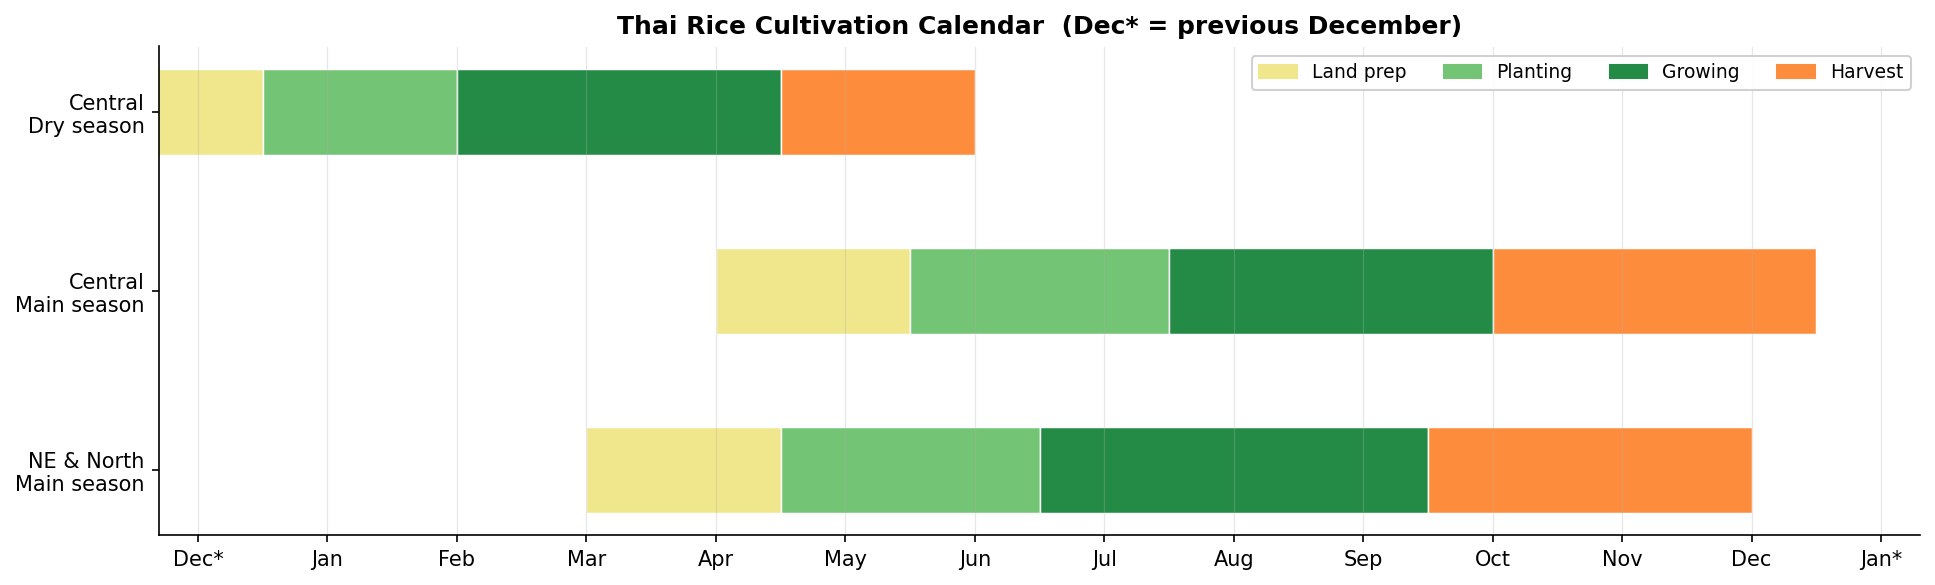

In [8]:
import matplotlib.gridspec as gridspec

# ── Load ONI for partial correlation (stored, not plotted) ───────────────────
oni = pd.read_csv("../data/raw/oni_growing_season.csv")
price_df2 = pd.read_csv("../data/processed/thailand_rice_price.csv")

nat2 = pd.read_csv("../data/raw/faostat_thailand_rice_1961_2024.csv")
area2 = nat2[nat2['Element']=='Area harvested'].rename(columns={'Year':'year','Value':'area_ha'})[['year','area_ha']].dropna()
yld2  = nat2[nat2['Element']=='Yield'].rename(columns={'Year':'year','Value':'yield_hg_ha'})[['year','yield_hg_ha']].dropna()
df_pc = area2.merge(yld2, on='year').merge(oni, on='year').merge(price_df2, on='year').dropna()

def partial_resid(x, z):
    s, i, *_ = stats.linregress(z, x)
    return x - (s * z + i)

area_r  = partial_resid(df_pc['area_ha'].values,          df_pc['oni_grow'].values)
price_r = partial_resid(df_pc['price_baht_tonne'].values, df_pc['oni_grow'].values)
rp, pp  = stats.pearsonr(price_r, area_r)
rb, pb  = stats.pearsonr(df_pc['price_baht_tonne'], df_pc['area_ha'])
print(f"Bivariate price–area:              r={rb:.3f}  p={pb:.3f}")
print(f"Partial (controlling ONI grow.):   r={rp:.3f}  p={pp:.3f}  n={len(df_pc)}")

# ════════════════════════════════════════════════════════════════════════════
# Plot 7 — Thai Rice Cultivation Calendar (Panel A only)
# ════════════════════════════════════════════════════════════════════════════
PH = {'Land prep':'#f0e68c', 'Planting':'#74c476',
      'Growing':'#238b45',   'Harvest':'#fd8d3c'}
CAL = [
    ('NE & North\nMain season', 'Land prep', 4.0, 1.5),
    ('NE & North\nMain season', 'Planting',  5.5, 2.0),
    ('NE & North\nMain season', 'Growing',   7.5, 3.0),
    ('NE & North\nMain season', 'Harvest',  10.5, 2.5),
    ('Central\nMain season',    'Land prep', 5.0, 1.5),
    ('Central\nMain season',    'Planting',  6.5, 2.0),
    ('Central\nMain season',    'Growing',   8.5, 2.5),
    ('Central\nMain season',    'Harvest',  11.0, 2.5),
    ('Central\nDry season',     'Land prep', 0.5, 1.0),
    ('Central\nDry season',     'Planting',  1.5, 1.5),
    ('Central\nDry season',     'Growing',   3.0, 2.5),
    ('Central\nDry season',     'Harvest',   5.5, 1.5),
]
ROWS  = ['NE & North\nMain season', 'Central\nMain season', 'Central\nDry season']
ROW_Y = {r: i for i, r in enumerate(ROWS)}

fig, ax = plt.subplots(figsize=(13, 4))
for row, phase, start, dur in CAL:
    ax.barh(ROW_Y[row], dur, left=start-1, height=0.48,
            color=PH[phase], edgecolor='white', lw=0.7)

ph_leg = [mpatches.Patch(color=c, label=l) for l, c in PH.items()]
ax.legend(handles=ph_leg, loc='upper right', fontsize=9, ncol=4, framealpha=0.9)

MONTH_TICKS = list(range(14))
MONTH_LABS  = ['Dec*','Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec','Jan*']
ax.set_xticks(MONTH_TICKS); ax.set_xticklabels(MONTH_LABS, fontsize=10)
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels(ROWS, fontsize=10)
ax.set_xlim(-0.3, 13.3)
ax.set_title('Thai Rice Cultivation Calendar  (Dec* = previous December)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/plot7_climate_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 8 — National Emission Intensity (kg CH₄ per tonne), 1961–2024

Intensity trend: -0.730 kg/t/yr | R²=0.892 | p=1.31e-31
1961 intensity: 92.5 kg/t
2024 intensity: 51.4 kg/t


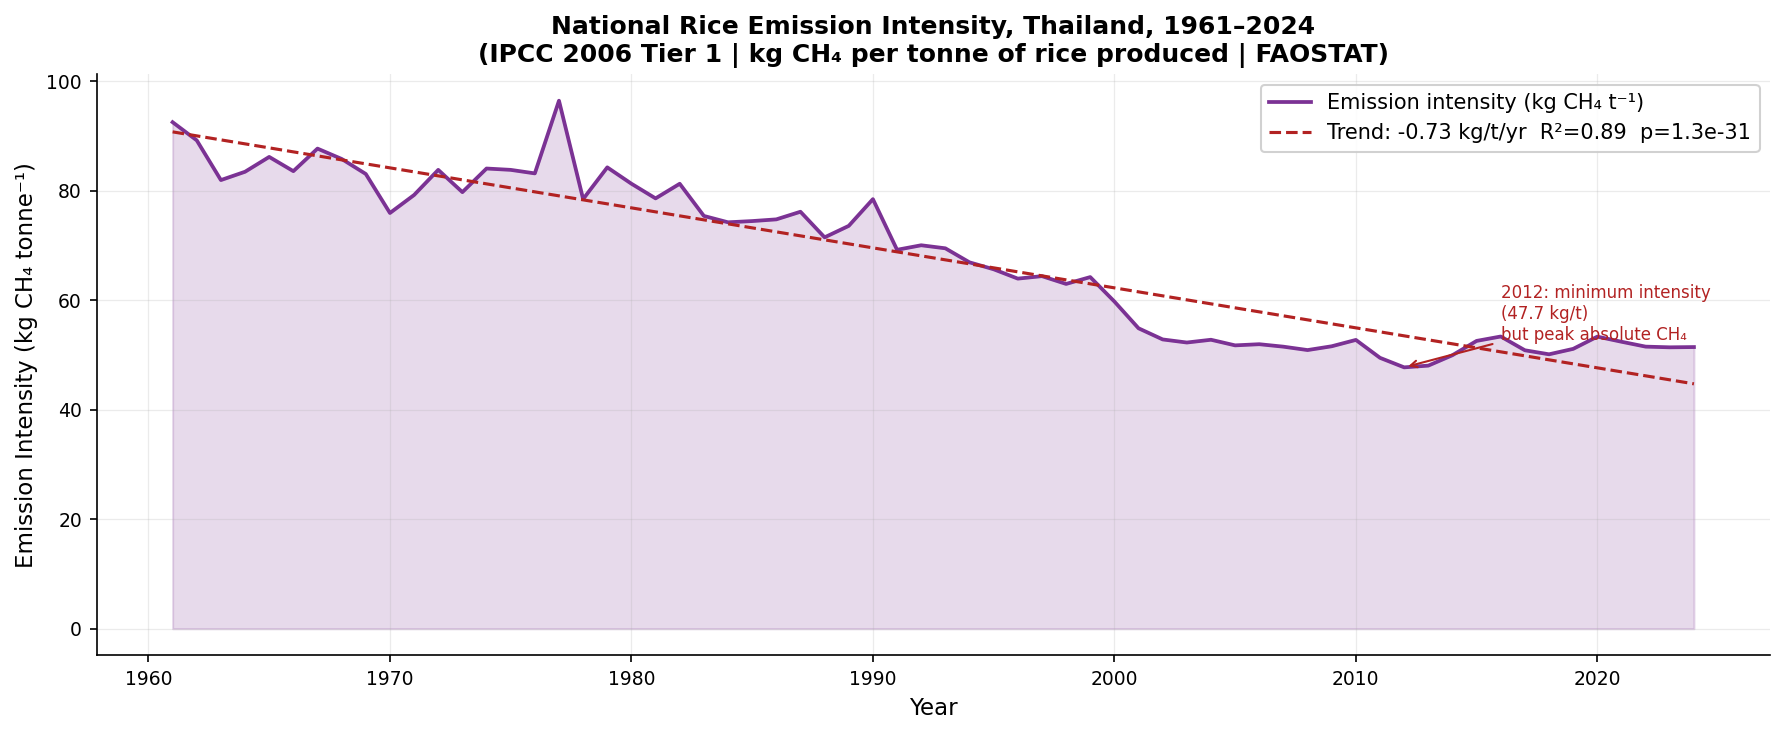

Saved → plot8_yield_efficiency.png


In [9]:
nat_full = pd.read_csv("../data/raw/faostat_thailand_rice_1961_2024.csv")
area_int = (nat_full[nat_full["Element"]=="Area harvested"]
            .rename(columns={"Year":"year","Value":"area_ha"})[["year","area_ha"]]
            .dropna().sort_values("year"))
prod_int = (nat_full[nat_full["Element"]=="Production"]
            .rename(columns={"Year":"year","Value":"production_t"})[["year","production_t"]]
            .dropna().sort_values("year"))

intensity_df = area_int.merge(prod_int, on="year")
intensity_df["CH4_Gg"]        = intensity_df["area_ha"] * 153.4 * 1e-6
intensity_df["intensity_kg_t"] = (intensity_df["CH4_Gg"] * 1e6) / intensity_df["production_t"]

sl, ic, r_int, p_int, _ = stats.linregress(intensity_df["year"], intensity_df["intensity_kg_t"])
trend_int = sl * intensity_df["year"] + ic
print(f"Intensity trend: {sl:.3f} kg/t/yr | R²={r_int**2:.3f} | p={p_int:.2e}")
print(f"1961 intensity: {intensity_df.iloc[0]['intensity_kg_t']:.1f} kg/t")
print(f"2024 intensity: {intensity_df.iloc[-1]['intensity_kg_t']:.1f} kg/t")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(intensity_df["year"], intensity_df["intensity_kg_t"], alpha=0.18, color="#7b3294")
ax.plot(intensity_df["year"], intensity_df["intensity_kg_t"], color="#7b3294", lw=1.8,
        label="Emission intensity (kg CH₄ t⁻¹)")
ax.plot(intensity_df["year"], trend_int, "--", color="firebrick", lw=1.5,
        label=f"Trend: {sl:.2f} kg/t/yr  R²={r_int**2:.2f}  p={p_int:.1e}")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Emission Intensity (kg CH₄ tonne⁻¹)", fontsize=11)
ax.set_title(
    "National Rice Emission Intensity, Thailand, 1961–2024\n"
    "(IPCC 2006 Tier 1 | kg CH₄ per tonne of rice produced | FAOSTAT)",
    fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

# Annotate 2012 paradox point
yr2012 = intensity_df[intensity_df["year"]==2012].iloc[0]
ax.annotate(f"2012: minimum intensity\n({yr2012['intensity_kg_t']:.1f} kg/t)\nbut peak absolute CH₄",
            xy=(2012, yr2012["intensity_kg_t"]),
            xytext=(2016, yr2012["intensity_kg_t"]+5),
            fontsize=8, color="firebrick",
            arrowprops=dict(arrowstyle="->", color="firebrick", lw=1))

plt.tight_layout()
plt.savefig("../figures/plot8_yield_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot8_yield_efficiency.png")

## Plot 9 — AWD Mitigation Priority Ranking by Province (fixed sort)

Top 10 AWD priority provinces (irrigated dry-season only, 50% scenario):
             province_en  region  dry_CH4_Gg  awd30_Gg  awd50_Gg
             Suphan Buri Central   19.386971  5.816091  9.693485
             Phitsanulok   North   15.683072  4.704922  7.841536
Phra Nakhon Si Ayutthaya Central   15.503234  4.650970  7.751617
            Nakhon Sawan Central   15.294270  4.588281  7.647135
                 Phichit   North   13.916431  4.174929  6.958215
          Kamphaeng Phet   North   11.706649  3.511995  5.853325
               Sukhothai   North   11.529483  3.458845  5.764742
                Chai Nat Central    9.512423  2.853727  4.756212
              Chiang Rai   North    9.236533  2.770960  4.618267
               Uttaradit   North    7.208345  2.162503  3.604172

National AWD totals (irrigated dry-season only):
  30% scenario: 57.3 Gg  (3.3% of 2024 national)
  50% scenario: 95.5 Gg  (5.5% of 2024 national)
  Top-4 share (50%): 32.93 / 95.5 = 34.5%


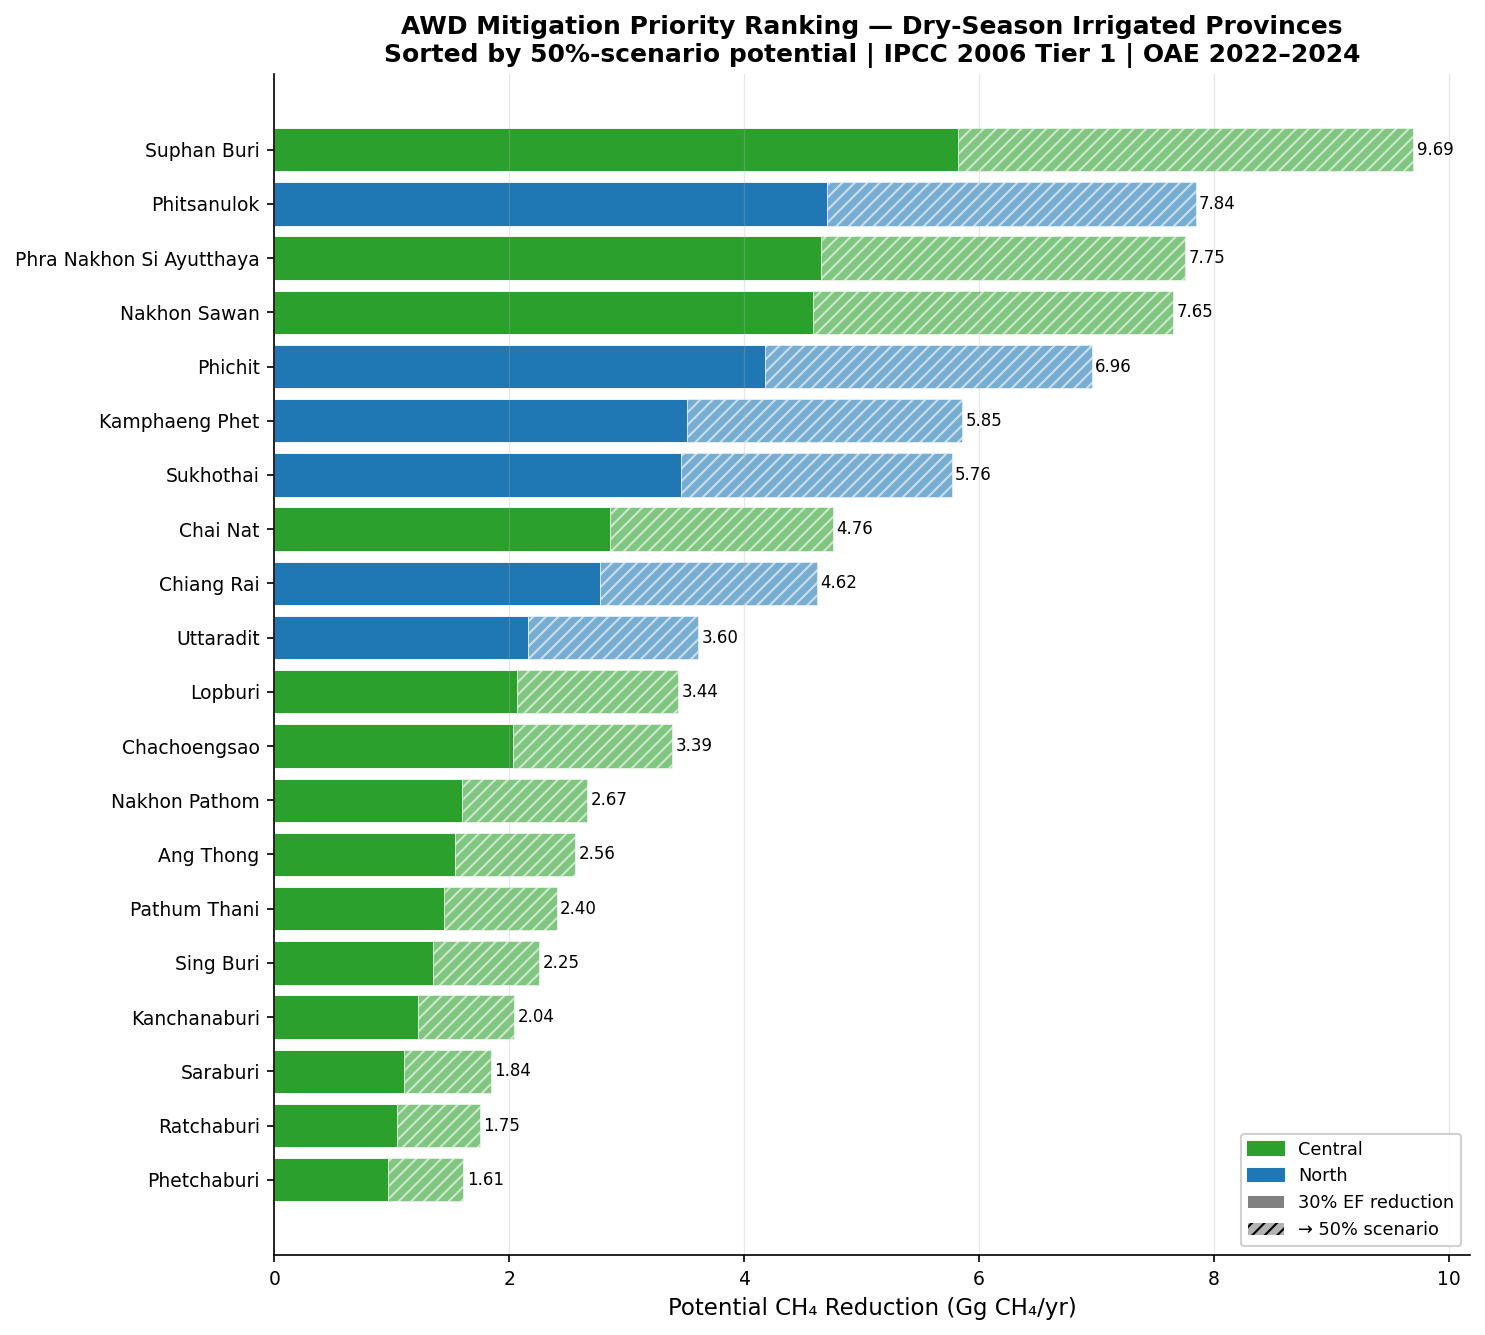

Saved → plot9_awd_priority.png


In [10]:
# AWD applies only to dry-season IRRIGATED area (SF_w = 1.0)
# Rainfed provinces (SF_w = 0.52) lack water control infrastructure for scheduled drainage
dry_df = df[df["season"] == "dry"].copy()
dry_df = dry_df[dry_df["SF_w"] == 1.0]   # irrigated only — fixes overestimation from rainfed dry area
dry_df["EF_kg_ha"] = T_P["dry"] * EF_c
dry_df["CH4_Gg"]   = dry_df["area_harvested_ha"] * dry_df["EF_kg_ha"] * 1e-6

dry_prov = (
    dry_df.groupby(["province_en", "region"])
    .agg(dry_area_ha=("area_harvested_ha", "mean"),
         dry_CH4_Gg=("CH4_Gg", "mean"))
    .reset_index()
)
# AWD scenarios: 30% EF reduction (solid bar) + extension to 50% (hatched)
dry_prov["awd30_Gg"] = dry_prov["dry_CH4_Gg"] * 0.30
dry_prov["awd50_Gg"] = dry_prov["dry_CH4_Gg"] * 0.50
dry_prov["ext20_Gg"] = dry_prov["awd50_Gg"] - dry_prov["awd30_Gg"]

# Sort by 50%-scenario total descending (priority = highest mitigation potential first)
dry_prov = dry_prov.sort_values("awd50_Gg", ascending=False).reset_index(drop=True)
top_n = dry_prov[dry_prov["awd50_Gg"] > 0].head(20)
# For barh: ascending=True so largest value ends up at the TOP of the chart
plot_data = top_n.sort_values("awd50_Gg", ascending=True).reset_index(drop=True)

nat30 = dry_prov["awd30_Gg"].sum()
nat50 = dry_prov["awd50_Gg"].sum()
top4_50 = dry_prov.head(4)["awd50_Gg"].sum()
print("Top 10 AWD priority provinces (irrigated dry-season only, 50% scenario):")
print(top_n.head(10)[["province_en","region","dry_CH4_Gg","awd30_Gg","awd50_Gg"]].to_string(index=False))
print(f"\nNational AWD totals (irrigated dry-season only):")
print(f"  30% scenario: {nat30:.1f} Gg  ({nat30/1725.5*100:.1f}% of 2024 national)")
print(f"  50% scenario: {nat50:.1f} Gg  ({nat50/1725.5*100:.1f}% of 2024 national)")
print(f"  Top-4 share (50%): {top4_50:.2f} / {nat50:.1f} = {top4_50/nat50*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 9))
colors = [REGION_COLORS[r] for r in plot_data["region"]]

# Solid bar: 30% reduction potential
ax.barh(plot_data["province_en"], plot_data["awd30_Gg"],
        color=colors, edgecolor="white", lw=0.4,
        label="30% EF reduction (AWD scenario)")
# Hatched extension: 30% → 50%
ax.barh(plot_data["province_en"], plot_data["ext20_Gg"],
        left=plot_data["awd30_Gg"],
        color=colors, edgecolor="white", lw=0.4, hatch="////", alpha=0.6,
        label="+20 pp extension (50% scenario)")

# Value labels (one loop only, using enumerate for categorical y positions)
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row["awd50_Gg"] + 0.03, i, f"{row['awd50_Gg']:.2f}",
            va="center", ha="left", fontsize=8)

legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()
                  if r in plot_data["region"].values]
legend_handles += [
    mpatches.Patch(facecolor="gray", label="30% EF reduction"),
    mpatches.Patch(facecolor="gray", hatch="////", alpha=0.6, label="→ 50% scenario"),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc="lower right")
ax.set_xlabel("Potential CH₄ Reduction (Gg CH₄/yr)", fontsize=11)
ax.set_title(
    "AWD Mitigation Priority Ranking — Dry-Season Irrigated Provinces\n"
    "Sorted by 50%-scenario potential | IPCC 2006 Tier 1 | OAE 2022–2024",
    fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/plot9_awd_priority.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot9_awd_priority.png")

## Robustness Check — Policy Dummy & Interrupted Time Series (ITS)
Tests whether the Rice Pledging Scheme (2011–2014) explains area variance beyond price alone. Two approaches:
1. **OLS with policy dummy**: area ~ price + pledging_dummy
2. **Chow test**: structural break at 2011 in price–area relationship

In [11]:
# ─── Policy dummy & ITS analysis ───────────────────────────────────────────
from scipy import stats
from scipy.stats import f as fdist
import numpy as np

price_df3 = pd.read_csv('../data/processed/thailand_rice_price.csv')
nat3 = pd.read_csv('../data/raw/faostat_thailand_rice_1961_2024.csv')
area3 = (nat3[nat3['Element']=='Area harvested']
          .rename(columns={'Year':'year','Value':'area_ha'})
          [['year','area_ha']].dropna().sort_values('year'))
m3 = area3.merge(price_df3, on='year').dropna()

# Policy dummy: 1 for 2011-2014 (Rice Pledging Scheme active)
m3 = m3.copy()
m3['pledging'] = ((m3['year'] >= 2011) & (m3['year'] <= 2014)).astype(int)
n = len(m3)
Y = m3['area_ha'].values
ss_tot = np.sum((Y - Y.mean())**2)

def ols(X, y):
    b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ b
    ss = np.sum((y - yhat)**2)
    return b, ss

# ── Model 1: price only ────────────────────────────────────────────────────
X1 = np.column_stack([np.ones(n), m3['price_baht_tonne']])
b1, ss1 = ols(X1, Y)
r2_1 = 1 - ss1/ss_tot
_, _, r1, p1, _ = stats.linregress(m3['price_baht_tonne'], Y)
print(f"Model 1 (price only):       r={r1:.3f}  p={p1:.3f}  R²={r2_1:.3f}")

# ── Model 2: price + pledging dummy ───────────────────────────────────────
X2 = np.column_stack([np.ones(n), m3['price_baht_tonne'], m3['pledging']])
b2, ss2 = ols(X2, Y)
r2_2 = 1 - ss2/ss_tot
F_add = ((ss1-ss2)/1) / (ss2/(n-3))
p_add = 1 - fdist.cdf(F_add, 1, n-3)
print(f"Model 2 (price + dummy):    R²={r2_2:.3f}")
print(f"  β_intercept = {b2[0]/1e6:.2f} M ha")
print(f"  β_price     = {b2[1]:.0f} ha per THB/t")
print(f"  β_pledging  = {b2[2]/1e6:.2f} M ha  (Pledging Scheme area premium)")
print(f"  F-test (dummy adds):  F={F_add:.2f}  p={p_add:.3f}  {'*' if p_add<0.05 else 'n.s.'}")

# ── Chow test: structural break at 2011 ───────────────────────────────────
pre  = m3[m3['year'] < 2011]
post = m3[m3['year'] >= 2011]

def seg_ols_ss(df):
    x = df['price_baht_tonne'].values
    y = df['area_ha'].values
    X = np.column_stack([np.ones(len(x)), x])
    _, ss = ols(X, y)
    return ss, len(df)

ss_pre, n_pre   = seg_ols_ss(pre)
ss_post, n_post = seg_ols_ss(post)
k = 2
chow_F = ((ss1 - (ss_pre+ss_post))/k) / ((ss_pre+ss_post)/(n-2*k))
p_chow = 1 - fdist.cdf(chow_F, k, n-2*k)
print(f"\nChow test (break at 2011):  F={chow_F:.2f}  p={p_chow:.3f}  {'*' if p_chow<0.05 else 'n.s.'}")
print(f"  Pre-2011  mean area: {pre['area_ha'].mean()/1e6:.2f} M ha  (n={n_pre})")
print(f"  Post-2011 mean area: {post['area_ha'].mean()/1e6:.2f} M ha  (n={n_post})")
print(f"  Difference:          {(post['area_ha'].mean()-pre['area_ha'].mean())/1e6:+.2f} M ha")
EF_national = 153.4  # kg/ha, main season (Buddhaboon et al. 2011)
print(f"\nNote: CH4 = {EF_national}e-6 * area_ha (main season EF, linear Tier 1 scaling).")
print("All area statistics translate directly to CH4 by multiplying by {EF_national}e-6.")

Model 1 (price only):       r=0.505  p=0.033  R²=0.255
Model 2 (price + dummy):    R²=0.631
  β_intercept = 8.87 M ha
  β_price     = 222 ha per THB/t
  β_pledging  = 0.99 M ha  (Pledging Scheme area premium)
  F-test (dummy adds):  F=15.27  p=0.001  *

Chow test (break at 2011):  F=0.98  p=0.401  n.s.
  Pre-2011  mean area: 10.91 M ha  (n=4)
  Post-2011 mean area: 11.04 M ha  (n=14)
  Difference:          +0.13 M ha

Note: CH4 = 153.4e-6 * area_ha (main season EF, linear Tier 1 scaling).
All area statistics translate directly to CH4 by multiplying by {EF_national}e-6.


## Monte Carlo Uncertainty Analysis
Propagates **SF_w and season-length uncertainty** through the Tier 1 emission equation.
EF_c = 1.30 kg CH4/ha/day is the fixed IPCC 2006 Tier 1 default and is not varied ---
the analysis specifically tests sensitivity to the regional SF_w grouping assumption.

**Uncertain parameters:**

| Parameter | Distribution | Range | Basis |
|-----------|-------------|-------|-------|
| EF_c | **Fixed** at 1.30 | -- | IPCC 2006 Table 5.11 Tier 1 default |
| SF_w rainfed (NE/South + overrides) | Uniform | [0.27, 0.71] | Full IPCC Table 5.12 rainfed regime range |
| SF_w irrigated (core Central/North) | Uniform | [0.61, 1.00] | Lower: Maneepitak 2019 AWD; upper: IPCC default |
| t_p main season | Normal (mu=118 d) | sigma=5 d | Province-level season length variation |
| t_p dry season | Normal (mu=111 d) | sigma=6 d | Same |

Activity data (OAE area) and EF_c treated as fixed.

Activity data (mean 2022–2024, SF_w-corrected provinces):
  Rainfed  main : 6.35 M ha
  Rainfed  dry  : 0.37 M ha
  Irrigated main: 3.32 M ha
  Irrigated dry : 1.25 M ha
  Total         : 11.29 M ha

Monte Carlo Results  (N = 10,000)
  Median            : 1054.2 Gg CH4/yr  (29.52 Mt CO2e/yr)
  Mean ± SD         : 1056.9 ± 155.6 Gg CH4/yr
  90% CI  [P5, P95] : [802.8, 1315.1] Gg CH4/yr
  50% CI [P25, P75] : [941.1, 1171.2] Gg CH4/yr
  CV (coefficient of variation): 14.7%


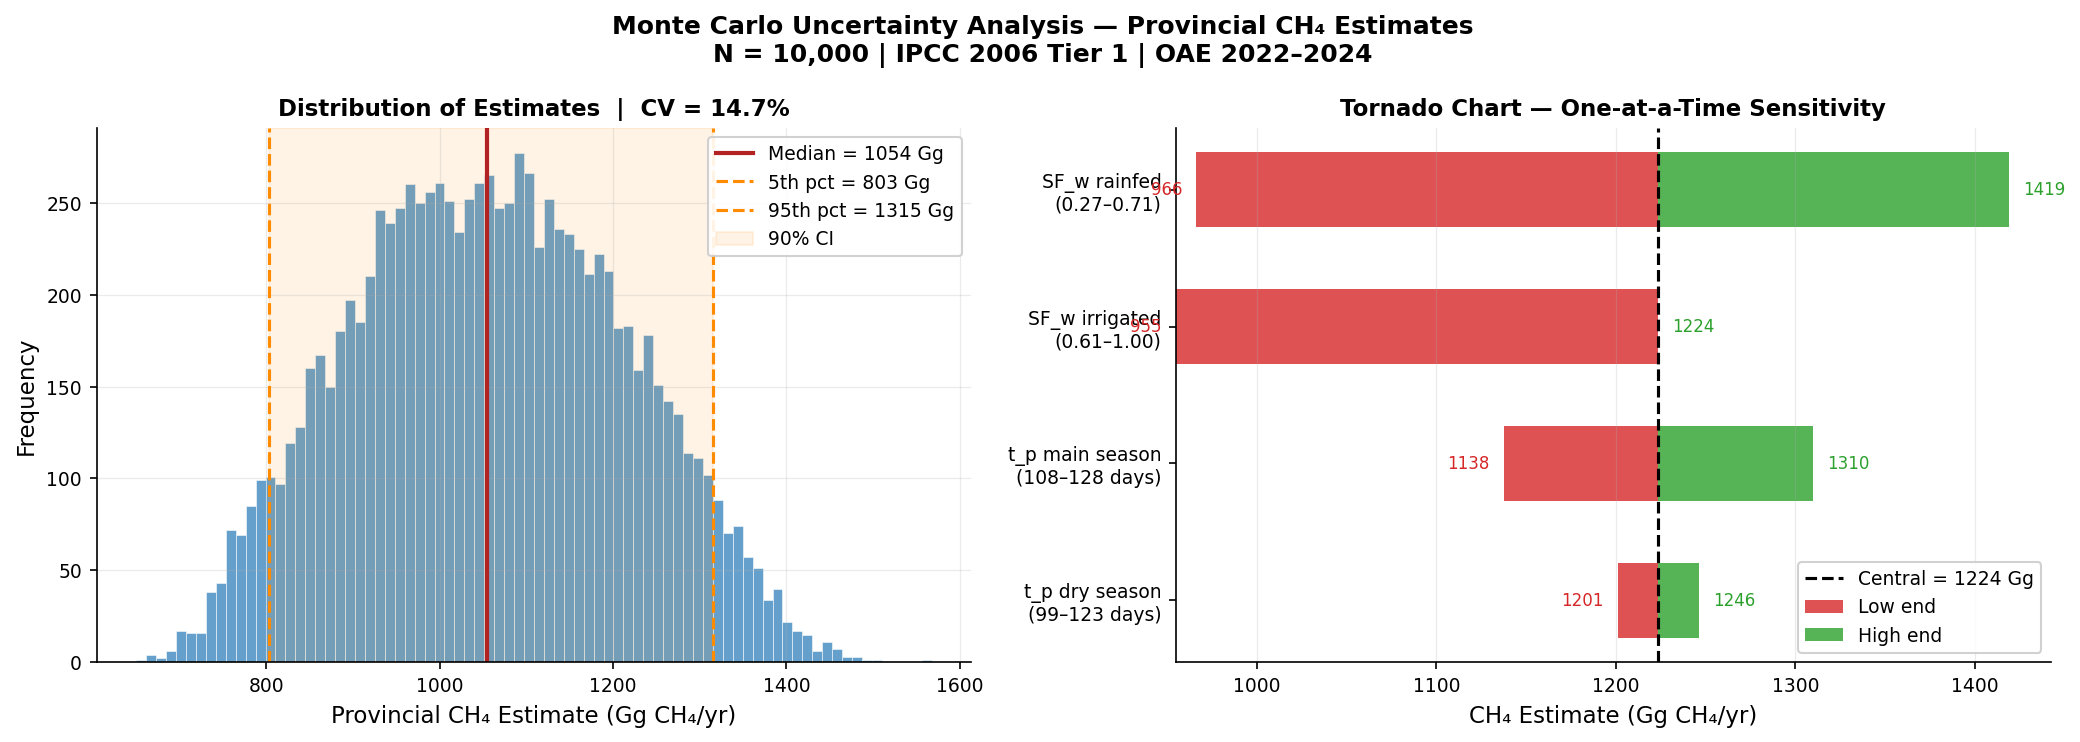

Saved → plot_mc_uncertainty.png


In [12]:
np.random.seed(42)
N = 10_000

# ── Aggregate area by water-regime class and season ──────────────────────────
# Use df which already has province-level SF_w applied
area_agg = (
    df[df["year_CE"] <= 2024]
    .groupby(["province_en", "season"])
    .agg(area_ha=("area_harvested_ha", "mean"),
         sf_w=("SF_w", "first"))
    .reset_index()
)
# Four buckets: rainfed×main, rainfed×dry, irrigated×main, irrigated×dry
A_rain_main = area_agg[(area_agg["sf_w"] == 0.52) & (area_agg["season"] == "main")]["area_ha"].sum()
A_rain_dry  = area_agg[(area_agg["sf_w"] == 0.52) & (area_agg["season"] == "dry" )]["area_ha"].sum()
A_irr_main  = area_agg[(area_agg["sf_w"] == 1.00) & (area_agg["season"] == "main")]["area_ha"].sum()
A_irr_dry   = area_agg[(area_agg["sf_w"] == 1.00) & (area_agg["season"] == "dry" )]["area_ha"].sum()
A_total     = A_rain_main + A_rain_dry + A_irr_main + A_irr_dry

print("Activity data (mean 2022–2024, SF_w-corrected provinces):")
print(f"  Rainfed  main : {A_rain_main/1e6:.2f} M ha")
print(f"  Rainfed  dry  : {A_rain_dry /1e6:.2f} M ha")
print(f"  Irrigated main: {A_irr_main /1e6:.2f} M ha")
print(f"  Irrigated dry : {A_irr_dry  /1e6:.2f} M ha")
print(f"  Total         : {A_total    /1e6:.2f} M ha")

# ── Sample parameter distributions ───────────────────────────────────────────
EF_c_s      = np.full(N, EF_c)                                     # fixed IPCC Tier 1 default
SF_rain_s   = np.random.uniform(0.27, 0.71, N)                     # uniform
SF_irr_s    = np.random.uniform(0.61, 1.00, N)                     # uniform — [0.61, 1.00]: lower bound from Maneepitak et al. (2019) Central Thailand AWD (34–39% EF reduction → SF_w ≈ 0.61–0.66)
tp_main_s   = np.random.normal(118, 5, N).clip(90, 140)            # normal, clipped
tp_dry_s    = np.random.normal(111, 6, N).clip(90, 140)            # normal, clipped

# ── CH4 = EF_c × (SF_w × t_p × Area) summed over all four buckets ────────────
CH4_mc = EF_c_s * (
    SF_rain_s * tp_main_s * A_rain_main +
    SF_rain_s * tp_dry_s  * A_rain_dry  +
    SF_irr_s  * tp_main_s * A_irr_main  +
    SF_irr_s  * tp_dry_s  * A_irr_dry
) * 1e-6   # Gg CH4/yr

CO2e_mc = CH4_mc * GWP / 1e3  # Mt CO2e/yr

med   = np.median(CH4_mc)
p5, p25, p75, p95 = np.percentile(CH4_mc, [5, 25, 75, 95])
cv    = np.std(CH4_mc) / np.mean(CH4_mc) * 100

print(f"\nMonte Carlo Results  (N = {N:,})")
print(f"  Median            : {med:.1f} Gg CH4/yr  ({med*GWP/1e3:.2f} Mt CO2e/yr)")
print(f"  Mean ± SD         : {np.mean(CH4_mc):.1f} ± {np.std(CH4_mc):.1f} Gg CH4/yr")
print(f"  90% CI  [P5, P95] : [{p5:.1f}, {p95:.1f}] Gg CH4/yr")
print(f"  50% CI [P25, P75] : [{p25:.1f}, {p75:.1f}] Gg CH4/yr")
print(f"  CV (coefficient of variation): {cv:.1f}%")

# ── Tornado chart: one-at-a-time sensitivity ──────────────────────────────────
def ch4_central(efc, sfr, sfi, tpm, tpd):
    return efc * (sfr*tpm*A_rain_main + sfr*tpd*A_rain_dry +
                  sfi*tpm*A_irr_main  + sfi*tpd*A_irr_dry) * 1e-6

central_val = ch4_central(1.30, 0.52, 1.00, 118, 111)

params = {
    "SF_w rainfed\n(0.27–0.71)":
        (ch4_central(1.30,  0.27, 1.00, 118, 111),
         ch4_central(1.30,  0.71, 1.00, 118, 111)),
    "SF_w irrigated\n(0.61–1.00)":
        (ch4_central(1.30,  0.52, 0.61, 118, 111),
         ch4_central(1.30,  0.52, 1.00, 118, 111)),
    "t_p main season\n(108–128 days)":
        (ch4_central(1.30,  0.52, 1.00, 108, 111),
         ch4_central(1.30,  0.52, 1.00, 128, 111)),
    "t_p dry season\n(99–123 days)":
        (ch4_central(1.30,  0.52, 1.00, 118,  99),
         ch4_central(1.30,  0.52, 1.00, 118, 123)),
}
# Sort by total range descending
params = dict(sorted(params.items(), key=lambda x: x[1][1]-x[1][0]))

# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Monte Carlo Uncertainty Analysis — Provincial CH₄ Estimates\n"
             f"N = {N:,} | IPCC 2006 Tier 1 | OAE 2022–2024",
             fontsize=12, fontweight="bold")

# --- Panel A: histogram --------------------------------------------------
ax = axes[0]
ax.hist(CH4_mc, bins=80, color="#4a90c4", edgecolor="white", linewidth=0.3, alpha=0.85)
ax.axvline(med,  color="firebrick",  lw=2,   linestyle="-",  label=f"Median = {med:.0f} Gg")
ax.axvline(p5,   color="darkorange", lw=1.5, linestyle="--", label=f"5th pct = {p5:.0f} Gg")
ax.axvline(p95,  color="darkorange", lw=1.5, linestyle="--", label=f"95th pct = {p95:.0f} Gg")
ax.axvspan(p5, p95, alpha=0.10, color="darkorange", label="90% CI")
ax.set_xlabel("Provincial CH₄ Estimate (Gg CH₄/yr)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title(f"Distribution of Estimates  |  CV = {cv:.1f}%", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

# --- Panel B: tornado chart ----------------------------------------------
ax = axes[1]
y_pos  = range(len(params))
labels = list(params.keys())
lows   = [v[0] for v in params.values()]
highs  = [v[1] for v in params.values()]
ranges = [h - l for l, h in zip(lows, highs)]

bars_low  = ax.barh(y_pos, [central_val - l for l in lows],  left=lows,
                    height=0.55, color="#d62728", alpha=0.80, label="Low end")
bars_high = ax.barh(y_pos, [h - central_val for h in highs], left=[central_val]*len(highs),
                    height=0.55, color="#2ca02c", alpha=0.80, label="High end")
ax.axvline(central_val, color="black", lw=1.5, linestyle="--", label=f"Central = {central_val:.0f} Gg")
for i, (l, h) in enumerate(zip(lows, highs)):
    ax.text(l - 8, i, f"{l:.0f}", va="center", ha="right", fontsize=8, color="#d62728")
    ax.text(h + 8, i, f"{h:.0f}", va="center", ha="left",  fontsize=8, color="#2ca02c")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("CH₄ Estimate (Gg CH₄/yr)", fontsize=11)
ax.set_title("Tornado Chart — One-at-a-Time Sensitivity", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/plot_mc_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → plot_mc_uncertainty.png")

## Province Emission Rank Uncertainty (Monte Carlo)

Point-estimate rankings mask parametric uncertainty. When SF_w varies (rainfed: 0.27–0.71 vs irrigated: 0.61–1.00), the rainfed/irrigated emission ratio shifts, reordering provinces. EF_c and t_p scale all provinces identically and do not affect rankings.

**Method:** Reuse the N=10,000 MC samples above. Build a (N × 76) emission matrix applying province-specific SF_w class to each draw. Rank all provinces in every iteration (rank 1 = highest emitter). Report median rank and 90% CI [P5, P95] per province.

Provinces: 77  |  Rainfed: 43  |  Irrigated: 34


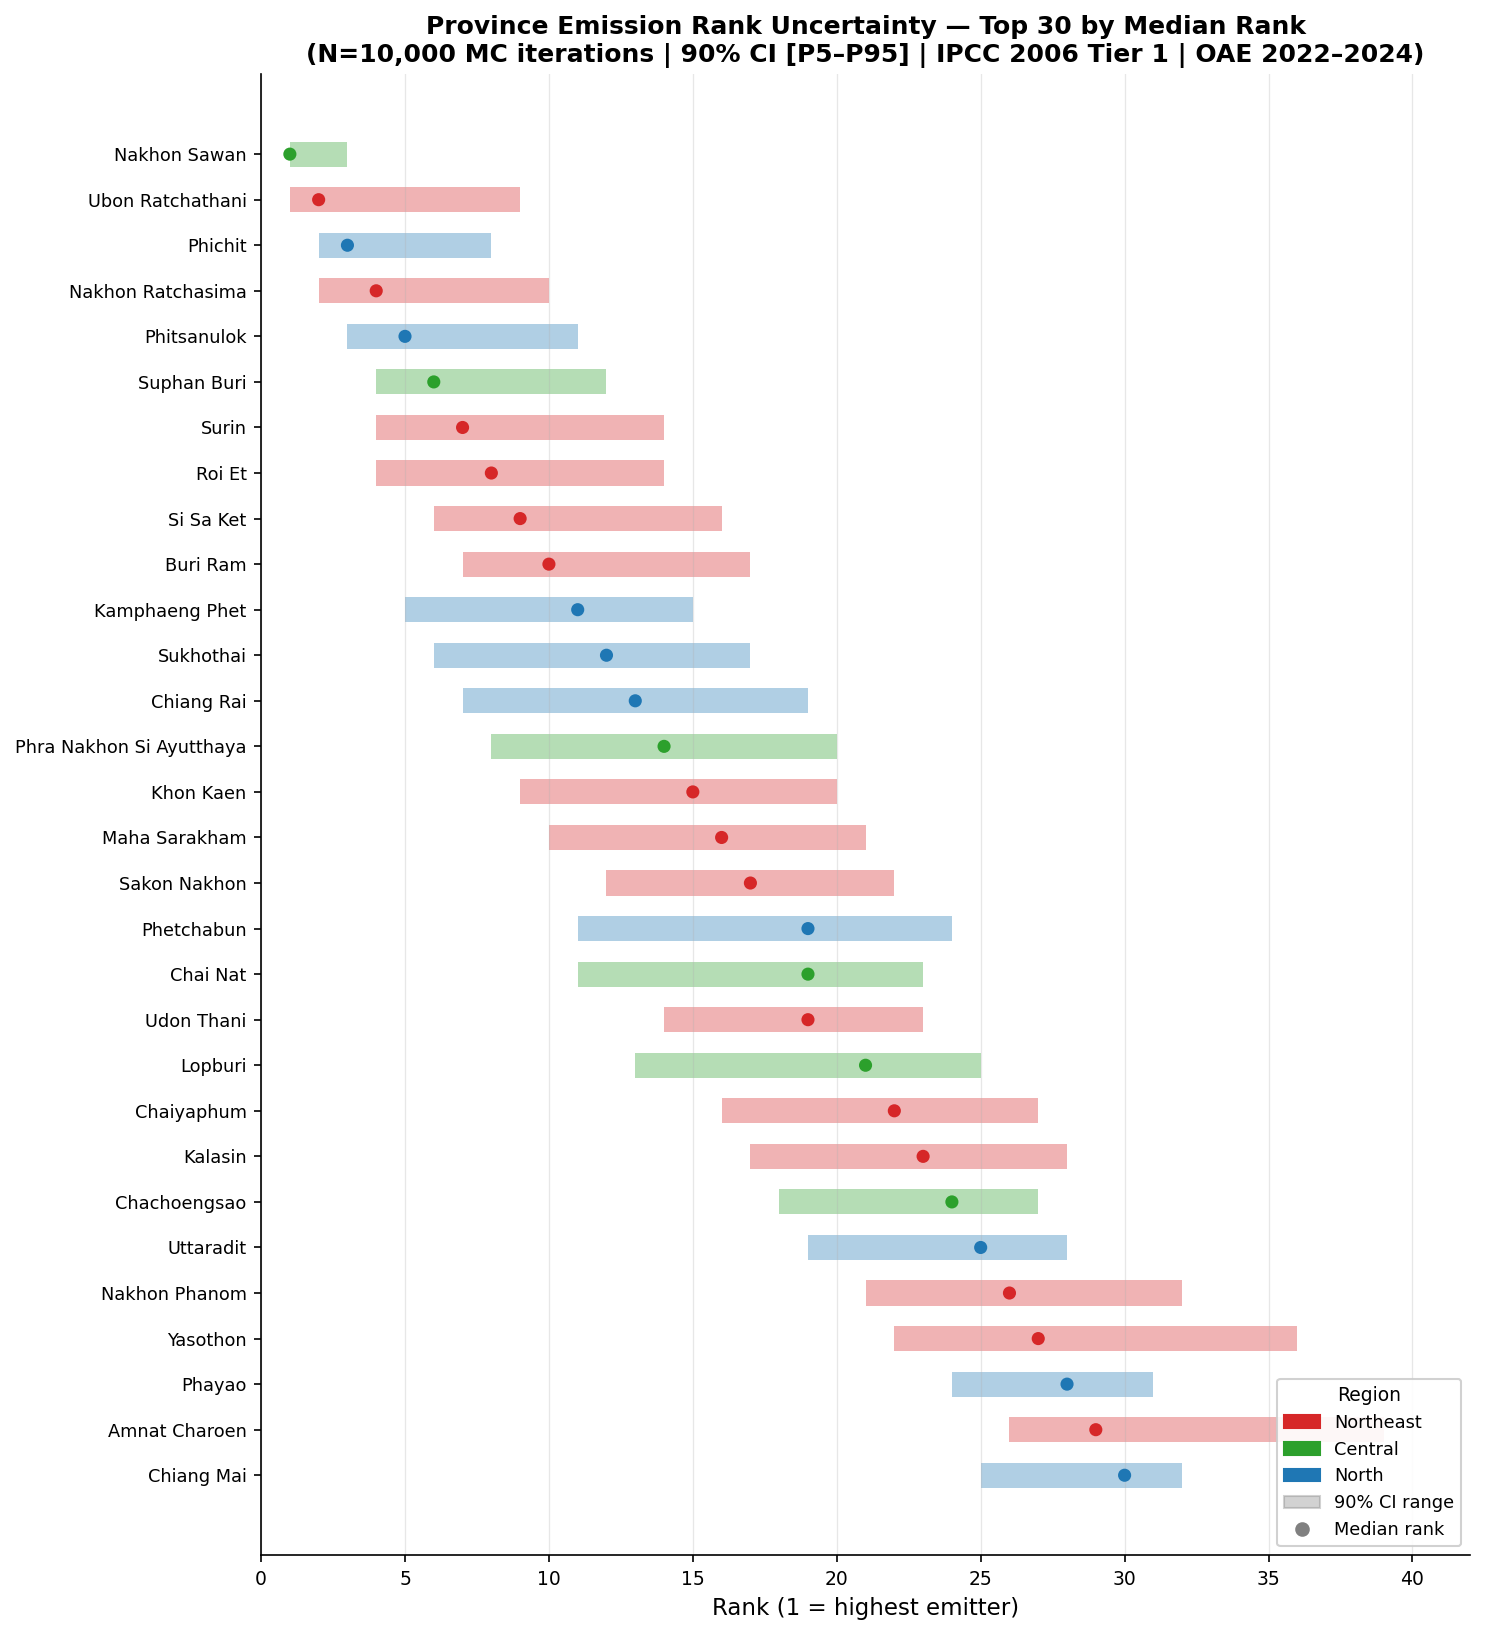

Top 15 provinces by median rank:
             province_en    region  rank_median  rank_p5  rank_p95  rank_range
            Nakhon Sawan   Central            1        1         3           2
        Ubon Ratchathani Northeast            2        1         9           8
                 Phichit     North            3        2         8           6
       Nakhon Ratchasima Northeast            4        2        10           8
             Phitsanulok     North            5        3        11           8
             Suphan Buri   Central            6        4        12           8
                   Surin Northeast            7        4        14          10
                  Roi Et Northeast            8        4        14          10
               Si Sa Ket Northeast            9        6        16          10
                Buri Ram Northeast           10        7        17          10
          Kamphaeng Phet     North           11        5        15          10
               Sukh

In [13]:
# ── Province activity: mean 2022-2024, both seasons ──────────────────────────
prov_activity = (
    df[df["year_CE"] <= 2024]
    .groupby(["province_en", "region", "season"])
    .agg(area_ha=("area_harvested_ha", "mean"), sf_w=("SF_w", "first"))
    .reset_index()
)
# Wide: one row per province, columns area_main / area_dry
prov_wide = (
    prov_activity.pivot_table(index=["province_en","region"], columns="season",
                               values="area_ha", aggfunc="mean")
    .fillna(0).reset_index()
)
prov_wide.columns.name = None
if "main" not in prov_wide.columns: prov_wide["main"] = 0.0
if "dry"  not in prov_wide.columns: prov_wide["dry"]  = 0.0

# SF_w class: same for both seasons per province
sf_lookup = prov_activity.groupby("province_en")["sf_w"].first()
prov_wide["sf_w"]       = prov_wide["province_en"].map(sf_lookup)
prov_wide["is_rainfed"] = (prov_wide["sf_w"] == 0.52)

n_prov        = len(prov_wide)
area_main_arr = prov_wide["main"].values        # (n_prov,)
area_dry_arr  = prov_wide["dry"].values         # (n_prov,)
is_rainfed    = prov_wide["is_rainfed"].values  # (n_prov,) bool

print(f"Provinces: {n_prov}  |  Rainfed: {is_rainfed.sum()}  |  Irrigated: {(~is_rainfed).sum()}")

# ── (N × n_prov) SF_w matrix ─────────────────────────────────────────────────
# Rainfed provinces draw from SF_rain_s; irrigated from SF_irr_s
SF_w_mc = np.where(
    is_rainfed[np.newaxis, :],
    SF_rain_s[:, np.newaxis],
    SF_irr_s[:, np.newaxis])  # (N, n_prov)

# ── (N × n_prov) emission matrix ─────────────────────────────────────────────
CH4_prov_mc = EF_c_s[:, np.newaxis] * (
    SF_w_mc * tp_main_s[:, np.newaxis] * area_main_arr[np.newaxis, :] +
    SF_w_mc * tp_dry_s[:, np.newaxis]  * area_dry_arr[np.newaxis, :]
) * 1e-6  # Gg CH4/yr per province per iteration

# ── Rank per iteration: rank 1 = highest emitter ─────────────────────────────
ranks_mc = np.argsort(np.argsort(-CH4_prov_mc, axis=1), axis=1) + 1  # (N, n_prov)

rank_median = np.median(ranks_mc, axis=0).astype(int)
rank_p5     = np.percentile(ranks_mc,  5, axis=0).astype(int)
rank_p95    = np.percentile(ranks_mc, 95, axis=0).astype(int)

prov_wide["rank_median"] = rank_median
prov_wide["rank_p5"]     = rank_p5
prov_wide["rank_p95"]    = rank_p95
prov_wide["rank_range"]  = rank_p95 - rank_p5

# ── Plot: top 30 by median rank ───────────────────────────────────────────────
top30 = (prov_wide.sort_values("rank_median").head(30)
                  .sort_values("rank_median", ascending=False)
                  .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 11))
colors = [REGION_COLORS[r] for r in top30["region"]]
y_pos  = np.arange(len(top30))

ax.barh(y_pos, top30["rank_p95"] - top30["rank_p5"],
        left=top30["rank_p5"], height=0.55,
        color=colors, alpha=0.35)
ax.scatter(top30["rank_median"], y_pos, color=colors, zorder=5, s=28)

ax.set_yticks(y_pos)
ax.set_yticklabels(top30["province_en"], fontsize=8.5)
ax.set_xlabel("Rank (1 = highest emitter)", fontsize=11)
ax.set_xlim(0, top30["rank_p95"].max() + 3)
ax.set_title(
    "Province Emission Rank Uncertainty — Top 30 by Median Rank\n"
    f"(N={N:,} MC iterations | 90% CI [P5–P95] | IPCC 2006 Tier 1 | OAE 2022–2024)",
    fontsize=12, fontweight="bold"
)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
legend_handles  = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()
                   if r in top30["region"].values]
legend_handles += [mpatches.Patch(color="gray", alpha=0.35, label="90% CI range"),
                   Line2D([0],[0], marker="o", color="gray", ms=6, ls="", label="Median rank")]
ax.legend(handles=legend_handles, title="Region", fontsize=8.5, title_fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("../figures/plot_rank_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
out_cols = ["province_en","region","rank_median","rank_p5","rank_p95","rank_range"]
print("Top 15 provinces by median rank:")
print(prov_wide.sort_values("rank_median").head(15)[out_cols].to_string(index=False))
print(f"\nMost rank-uncertain in top 15 (widest 90% CI):")
print(prov_wide.sort_values("rank_median").head(15)
               .nlargest(5,"rank_range")[out_cols].to_string(index=False))

## MC-Updated Intensity Ranking & Choropleth

Redoes Plot 5 (intensity) and Plot 4 (choropleth) using Monte Carlo results:
- **Intensity rank chart**: ranks provinces by kg CH₄/tonne across all N=10,000 draws; shows 90% CI per province
- **Choropleth pair**: left = MC median emission (replaces point estimate); right = 90% CI width (shows which provinces have high parametric uncertainty)

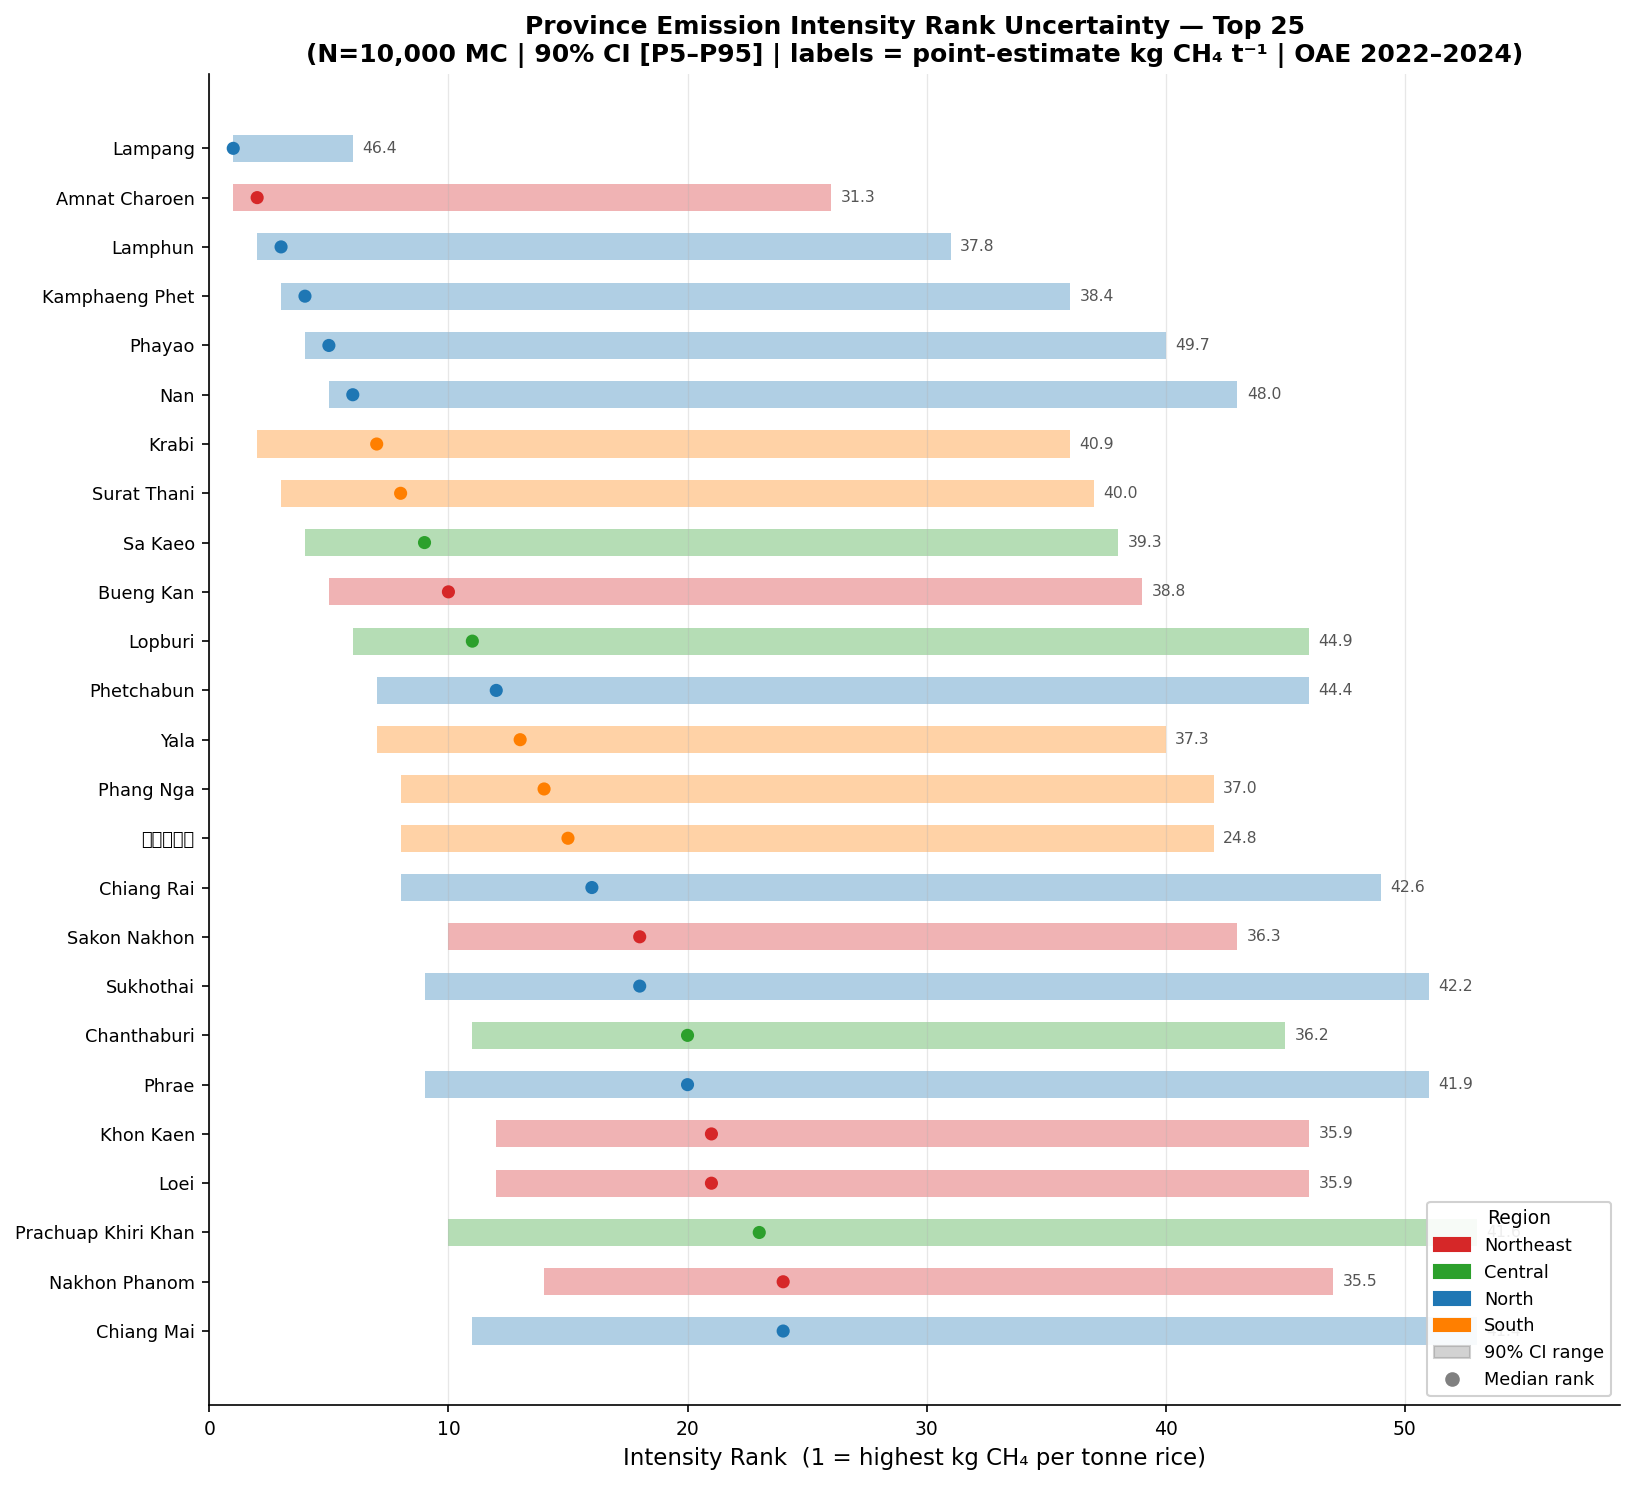

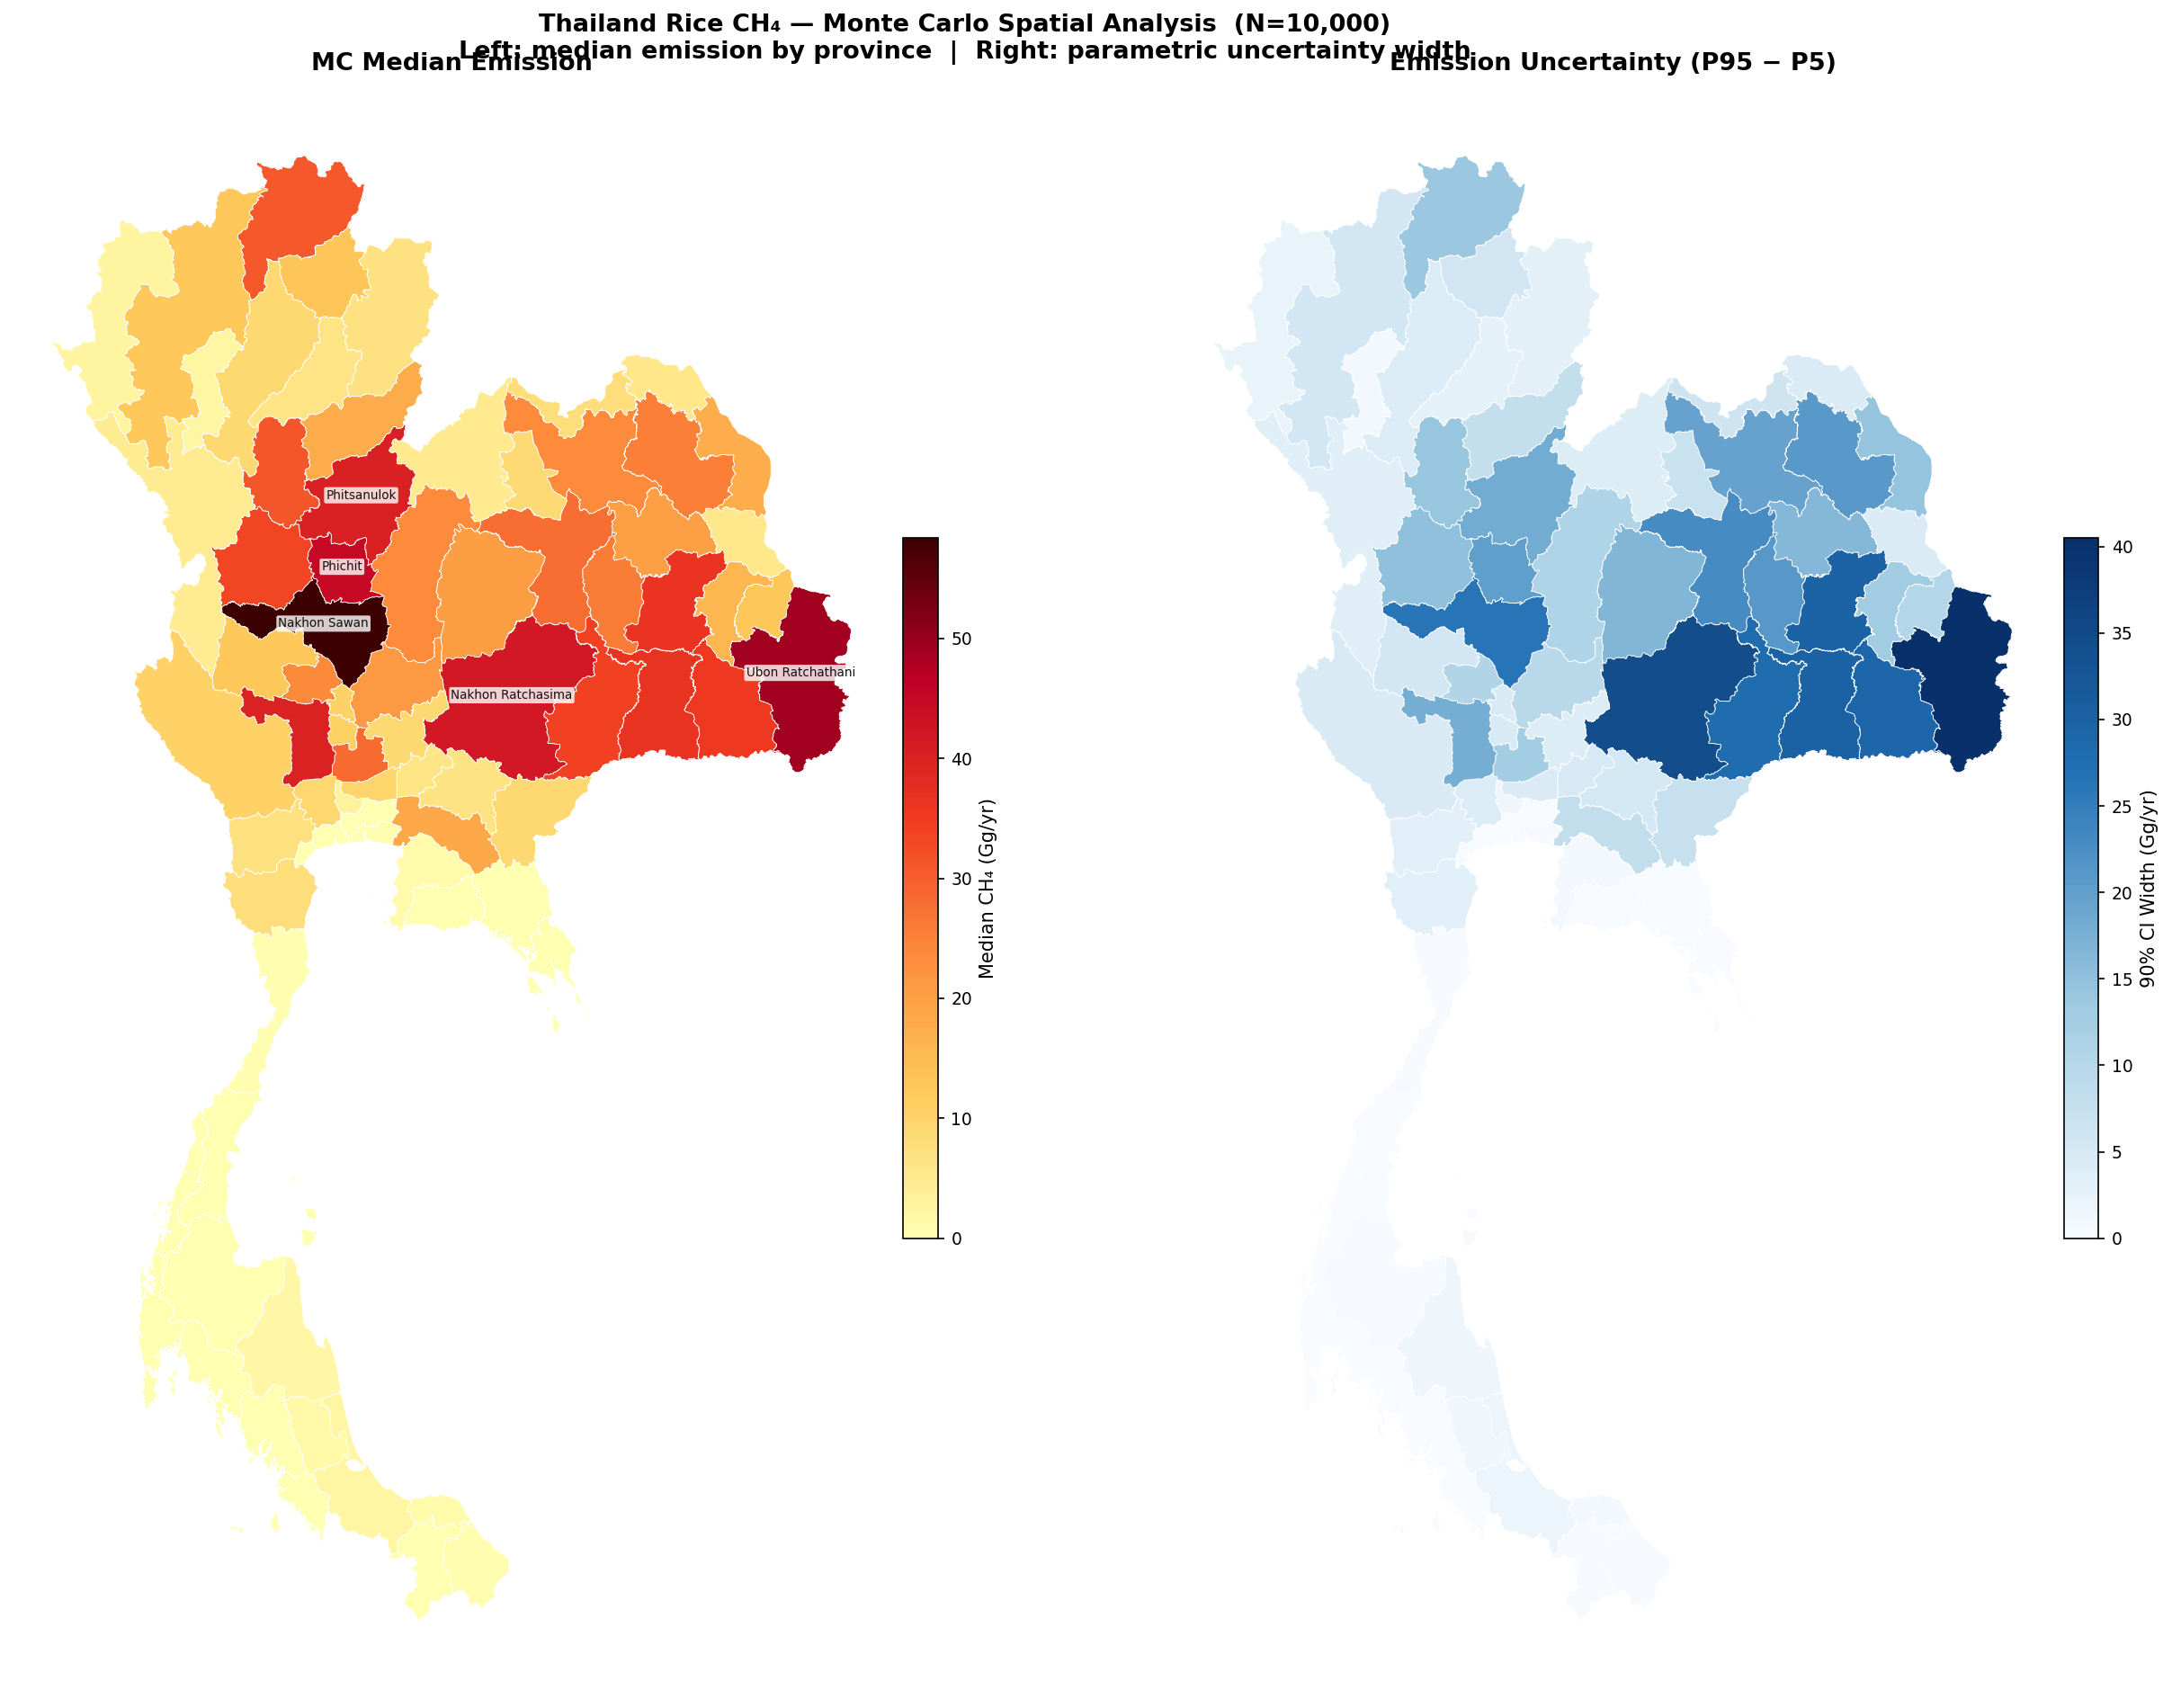

Saved → plot5_intensity_rank.png  |  plot4_choropleth_mc.png


In [14]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ── Attach production to prov_wide for intensity calculation ─────────────────
prod_lookup = mean_prov.set_index("province_en")["production_t"]
prov_wide["production_t"] = prov_wide["province_en"].map(prod_lookup).fillna(1)

# ── MC intensity: (N × n_prov) in kg CH4/tonne ───────────────────────────────
prod_arr     = prov_wide["production_t"].values        # (n_prov,)
intensity_mc = (CH4_prov_mc * 1e6) / prod_arr[np.newaxis, :]  # (N, n_prov)

# Rank by intensity: rank 1 = highest kg CH4/tonne
int_ranks_mc       = np.argsort(np.argsort(-intensity_mc, axis=1), axis=1) + 1
int_rank_median    = np.median(int_ranks_mc, axis=0).astype(int)
int_rank_p5        = np.percentile(int_ranks_mc,  5, axis=0).astype(int)
int_rank_p95       = np.percentile(int_ranks_mc, 95, axis=0).astype(int)

prov_wide["int_rank_median"] = int_rank_median
prov_wide["int_rank_p5"]     = int_rank_p5
prov_wide["int_rank_p95"]    = int_rank_p95
prov_wide["int_rank_range"]  = int_rank_p95 - int_rank_p5

# Point-estimate intensity (for label)
int_pt_lookup = mean_prov.set_index("province_en")["intensity_kgCH4_t"]
prov_wide["intensity_pt"] = prov_wide["province_en"].map(int_pt_lookup)

# ── Plot: top 25 intensity provinces with rank CI ────────────────────────────
top25_int = (prov_wide.sort_values("int_rank_median").head(25)
                      .sort_values("int_rank_median", ascending=False)
                      .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 10))
colors = [REGION_COLORS[r] for r in top25_int["region"]]
y_pos  = np.arange(len(top25_int))

ax.barh(y_pos, top25_int["int_rank_p95"] - top25_int["int_rank_p5"],
        left=top25_int["int_rank_p5"], height=0.55,
        color=colors, alpha=0.35)
ax.scatter(top25_int["int_rank_median"], y_pos, color=colors, zorder=5, s=28)

for i, (_, row) in enumerate(top25_int.iterrows()):
    ax.text(row["int_rank_p95"] + 0.4, i, f"{row['intensity_pt']:.1f}",
            va="center", ha="left", fontsize=7.5, color="#555555")

ax.set_yticks(y_pos)
ax.set_yticklabels(top25_int["province_en"], fontsize=8.5)
ax.set_xlabel("Intensity Rank  (1 = highest kg CH₄ per tonne rice)", fontsize=11)
ax.set_xlim(0, top25_int["int_rank_p95"].max() + 6)
ax.set_title(
    "Province Emission Intensity Rank Uncertainty — Top 25\n"
    f"(N={N:,} MC | 90% CI [P5–P95] | labels = point-estimate kg CH₄ t⁻¹ | OAE 2022–2024)",
    fontsize=12, fontweight="bold"
)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
legend_handles  = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()
                   if r in top25_int["region"].values]
legend_handles += [mpatches.Patch(color="gray", alpha=0.35, label="90% CI range"),
                   Line2D([0],[0], marker="o", color="gray", ms=6, ls="", label="Median rank")]
ax.legend(handles=legend_handles, title="Region", fontsize=8.5, title_fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("../figures/plot5_intensity_rank.png", dpi=150, bbox_inches="tight")
plt.show()

# ── MC median + CI width per province ────────────────────────────────────────
prov_wide["CH4_mc_median"] = np.median(CH4_prov_mc, axis=0)
prov_wide["CH4_mc_p5"]     = np.percentile(CH4_prov_mc,  5, axis=0)
prov_wide["CH4_mc_p95"]    = np.percentile(CH4_prov_mc, 95, axis=0)
prov_wide["CH4_mc_range"]  = prov_wide["CH4_mc_p95"] - prov_wide["CH4_mc_p5"]

# ── Choropleth: MC median (left) + 90% CI width (right) ──────────────────────
cmap_yor = LinearSegmentedColormap.from_list(
    "yor_dark",
    ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026", "#3d0000"], N=256)
cmap_unc = LinearSegmentedColormap.from_list(
    "unc", ["#f7fbff", "#9ecae1", "#2171b5", "#08306b"], N=256)

GADM_FIX = {
    "Krung Thep Maha Nakhon":"Bangkok","Lop Buri":"Lopburi",
    "Nong Bua Lam Phu":"Nong Bua Lamphu",
    "Phra Nakhon Si Ayutthaya":"Phra Nakhon Si Ayutthaya",
}
gdf2 = gpd.read_file("../data/raw/gadm_THA/gadm41_THA_1.shp")
gdf2["province_en"] = gdf2["NAME_1"].map(GADM_FIX).fillna(gdf2["NAME_1"])

geo_mc = gdf2.merge(
    prov_wide[["province_en","CH4_mc_median","CH4_mc_range","rank_median"]],
    on="province_en", how="left"
).fillna({"CH4_mc_median": 0, "CH4_mc_range": 0})

fig, axes = plt.subplots(1, 2, figsize=(18, 13))

for ax, col, cmap, cbar_lbl, subtitle in [
    (axes[0], "CH4_mc_median", cmap_yor,
     "Median CH₄ (Gg/yr)", "MC Median Emission"),
    (axes[1], "CH4_mc_range",  cmap_unc,
     "90% CI Width (Gg/yr)", "Emission Uncertainty (P95 − P5)"),
]:
    vmin = geo_mc[col].min(); vmax = geo_mc[col].max()
    geo_mc.plot(column=col, ax=ax, cmap=cmap,
                vmin=vmin, vmax=vmax,
                edgecolor="white", linewidth=0.4,
                missing_kwds={"color":"#eeeeee"})
    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                        fraction=0.03, pad=0.01, shrink=0.45)
    cbar.set_label(cbar_lbl, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=13, fontweight="bold", pad=6)

# Label top 5 on median map
top5 = prov_wide.sort_values("rank_median").head(5)
for _, row in top5.iterrows():
    match = geo_mc[geo_mc["province_en"] == row["province_en"]]
    if match.empty: continue
    pt = match.geometry.iloc[0].centroid
    axes[0].annotate(row["province_en"], xy=(pt.x, pt.y), fontsize=6.5,
                     ha="center", color="#111",
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.8, ec="none"))

fig.suptitle(
    "Thailand Rice CH₄ — Monte Carlo Spatial Analysis  (N=10,000)\n"
    "Left: median emission by province  |  Right: parametric uncertainty width",
    fontsize=13, fontweight="bold", y=0.97)
plt.tight_layout()
plt.savefig("../figures/plot4_choropleth_mc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot5_intensity_rank.png  |  plot4_choropleth_mc.png")